# Motor Insurance Pricing Analytics

## Project Overview

This project develops an end-to-end motor insurance pricing workflow using Python and the French Motor Third-Party Liability dataset.

The analysis examines policy exposure, claim frequency, claim severity and customer risk characteristics to estimate expected claim costs and support risk-based premium recommendations.

The project covers:

- data acquisition and validation;
- exploratory data analysis;
- claim frequency modelling;
- claim severity modelling;
- expected loss estimation;
- risk segmentation; and
- premium recommendations.

## 1. Import Libraries

This section imports the Python libraries required for data processing, statistical analysis, modelling and visualisation.

In [163]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.datasets import fetch_openml

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

## 2. Load the Data

The project uses two related datasets:

- **Frequency data:** policy-level information, policy exposure and claim counts.
- **Severity data:** individual claim amounts linked to policies through `IDpol`.

The datasets are retrieved from OpenML using their unique dataset identifiers and then saved locally to make the project reproducible.

In [164]:
# Define project paths
project_root = Path.cwd().parent
data_dir = project_root / "data"

# Ensure the data directory exists
data_dir.mkdir(parents=True, exist_ok=True)

print(f"Project root: {project_root}")
print(f"Data directory: {data_dir}")

Project root: c:\Files fromOneDrive\Actuarial Business Analysis\Motor-Insurance-Pricing-Analytics
Data directory: c:\Files fromOneDrive\Actuarial Business Analysis\Motor-Insurance-Pricing-Analytics\data


In [165]:
# Download the French motor insurance datasets from OpenML
frequency_openml = fetch_openml(
    data_id=41214,
    as_frame=True,
    parser="auto"
)

severity_openml = fetch_openml(
    data_id=41215,
    as_frame=True,
    parser="auto"
)

frequency_data = frequency_openml.data.copy()
severity_data = severity_openml.data.copy()

print("Datasets downloaded successfully.")

Datasets downloaded successfully.


In [166]:
# Standardise the policy identifier
frequency_data["IDpol"] = frequency_data["IDpol"].astype(int)
severity_data["IDpol"] = severity_data["IDpol"].astype(int)

# Display dataset dimensions
print(f"Frequency dataset: {frequency_data.shape[0]:,} rows and "
      f"{frequency_data.shape[1]} columns")

print(f"Severity dataset: {severity_data.shape[0]:,} rows and "
      f"{severity_data.shape[1]} columns")

Frequency dataset: 678,013 rows and 12 columns
Severity dataset: 26,639 rows and 2 columns


In [167]:
# Preview the frequency dataset
frequency_data.head()

,IDpol,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region
0,1,1,0.1000,D,5,0,55,50,B12,'Regular',1217,R82
1,3,1,0.7700,D,5,0,55,50,B12,'Regular',1217,R82
2,5,1,0.7500,B,6,2,52,50,B12,'Diesel',54,R22
3,10,1,0.0900,B,7,0,46,50,B12,'Diesel',76,R72
4,11,1,0.8400,B,7,0,46,50,B12,'Diesel',76,R72


In [168]:
# Preview the severity dataset
severity_data.head()

,IDpol,ClaimAmount
0,1552,995.2000
1,1010996,"1,128.1200"
2,4024277,"1,851.1100"
3,4007252,"1,204.0000"
4,4046424,"1,204.0000"


In [169]:
# Save local copies of the raw datasets
frequency_file = data_dir / "freMTPL2freq.csv"
severity_file = data_dir / "freMTPL2sev.csv"

frequency_data.to_csv(frequency_file, index=False)
severity_data.to_csv(severity_file, index=False)

print(f"Frequency data saved to: {frequency_file}")
print(f"Severity data saved to: {severity_file}")

Frequency data saved to: c:\Files fromOneDrive\Actuarial Business Analysis\Motor-Insurance-Pricing-Analytics\data\freMTPL2freq.csv
Severity data saved to: c:\Files fromOneDrive\Actuarial Business Analysis\Motor-Insurance-Pricing-Analytics\data\freMTPL2sev.csv


## 3. Initial Data Exploration

This section provides an overview of the datasets by examining their structure, variable types, missing values and summary statistics.

Understanding the data before modelling helps identify potential quality issues and supports appropriate analytical decisions.

In [170]:
# Dataset dimensions

print("=" * 60)
print("FREQUENCY DATASET")
print("=" * 60)

print(f"Rows    : {frequency_data.shape[0]:,}")
print(f"Columns : {frequency_data.shape[1]}")

print()

print("=" * 60)
print("SEVERITY DATASET")
print("=" * 60)

print(f"Rows    : {severity_data.shape[0]:,}")
print(f"Columns : {severity_data.shape[1]}")

FREQUENCY DATASET
Rows    : 678,013
Columns : 12

SEVERITY DATASET
Rows    : 26,639
Columns : 2


In [171]:
# Display column names

print("Frequency Dataset Columns")

for column in frequency_data.columns:
    print(column)

print()

print("Severity Dataset Columns")

for column in severity_data.columns:
    print(column)

Frequency Dataset Columns
IDpol
ClaimNb
Exposure
Area
VehPower
VehAge
DrivAge
BonusMalus
VehBrand
VehGas
Density
Region

Severity Dataset Columns
IDpol
ClaimAmount


In [172]:
# Data types

frequency_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 678013 entries, 0 to 678012
Data columns (total 12 columns):
 #   Column      Non-Null Count   Dtype   
---  ------      --------------   -----   
 0   IDpol       678013 non-null  int64   
 1   ClaimNb     678013 non-null  int64   
 2   Exposure    678013 non-null  float64 
 3   Area        678013 non-null  category
 4   VehPower    678013 non-null  int64   
 5   VehAge      678013 non-null  int64   
 6   DrivAge     678013 non-null  int64   
 7   BonusMalus  678013 non-null  int64   
 8   VehBrand    678013 non-null  category
 9   VehGas      678013 non-null  object  
 10  Density     678013 non-null  int64   
 11  Region      678013 non-null  category
dtypes: category(3), float64(1), int64(7), object(1)
memory usage: 48.5+ MB


In [173]:
severity_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26639 entries, 0 to 26638
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   IDpol        26639 non-null  int64  
 1   ClaimAmount  26639 non-null  float64
dtypes: float64(1), int64(1)
memory usage: 416.4 KB


In [174]:
# Missing values

frequency_missing = frequency_data.isnull().sum()

frequency_missing = (
    frequency_missing[frequency_missing > 0]
    .sort_values(ascending=False)
)

frequency_missing

Series([], dtype: int64)

In [175]:
severity_missing = severity_data.isnull().sum()

severity_missing = (
    severity_missing[severity_missing > 0]
    .sort_values(ascending=False)
)

severity_missing

Series([], dtype: int64)

In [176]:
# Summary statistics

frequency_data.describe(include="all")

,IDpol,ClaimNb,Exposure,Area,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region
count,"678,013.0000","678,013.0000","678,013.0000",678013,"678,013.0000","678,013.0000","678,013.0000","678,013.0000",678013,678013,"678,013.0000",678013
unique,NaN,NaN,NaN,6,NaN,NaN,NaN,NaN,11,2,NaN,22
top,NaN,NaN,NaN,C,NaN,NaN,NaN,NaN,B12,'Regular',NaN,R24
freq,NaN,NaN,NaN,191880,NaN,NaN,NaN,NaN,166024,345877,NaN,160601
mean,"2,621,856.9211",0.0532,0.5288,NaN,6.4546,7.0443,45.4991,59.7615,NaN,NaN,"1,792.4224",NaN
std,"1,641,782.7527",0.2401,0.3644,NaN,2.0509,5.6662,14.1374,15.6367,NaN,NaN,"3,958.6466",NaN
min,1.0000,0.0000,0.0027,NaN,4.0000,0.0000,18.0000,50.0000,NaN,NaN,1.0000,NaN
25%,"1,157,951.0000",0.0000,0.1800,NaN,5.0000,2.0000,34.0000,50.0000,NaN,NaN,92.0000,NaN
50%,"2,272,152.0000",0.0000,0.4900,NaN,6.0000,6.0000,44.0000,50.0000,NaN,NaN,393.0000,NaN
75%,"4,046,274.0000",0.0000,0.9900,NaN,7.0000,11.0000,55.0000,64.0000,NaN,NaN,"1,658.0000",NaN


In [177]:
severity_data.describe(include="all")

,IDpol,ClaimAmount
count,"26,639.0000","26,639.0000"
mean,"2,279,863.8311","2,278.5364"
std,"1,577,201.8069","29,297.4813"
min,139.0000,1.0000
25%,"1,087,642.5000",686.8100
50%,"2,137,413.0000","1,172.0000"
75%,"3,180,162.0000","1,228.0800"
max,"6,113,971.0000","4,075,400.5600"


In [178]:
# Duplicate records

print("Frequency duplicates:",
      frequency_data.duplicated().sum())

print("Severity duplicates:",
      severity_data.duplicated().sum())

Frequency duplicates: 0
Severity duplicates: 255


### Initial Observations

The initial exploration indicates that both datasets have been successfully loaded and are suitable for actuarial pricing analysis.

Key observations include:

- The frequency dataset contains **678,013 insurance policies** with **12 variables**.
- The severity dataset contains **26,639 individual claims** linked through the policy identifier (`IDpol`).
- No missing values were identified in either dataset.
- Data types are appropriate for the variables represented.
- The dataset contains a mixture of numerical and categorical risk characteristics commonly used in motor insurance pricing.
- The policy identifier provides a reliable key for linking claim frequency and claim severity information.
- Overall, the datasets appear to be of high quality and require only limited preprocessing before modelling.

## 4. Data Quality Assessment

This section evaluates the completeness, consistency and validity of the datasets before further analysis.

The objective is to identify potential data quality issues that could affect actuarial pricing models.

In [179]:
# Missing values

missing_summary = pd.DataFrame({
    "Frequency Dataset": frequency_data.isnull().sum(),
    "Severity Dataset": severity_data.reindex(
        columns=frequency_data.columns,
        fill_value=np.nan
    ).isnull().sum()
})

missing_summary

,Frequency Dataset,Severity Dataset
IDpol,0,0
ClaimNb,0,26639
Exposure,0,26639
Area,0,26639
VehPower,0,26639
VehAge,0,26639
DrivAge,0,26639
BonusMalus,0,26639
VehBrand,0,26639
VehGas,0,26639


In [180]:
duplicate_summary = pd.DataFrame({

    "Dataset": [

        "Frequency",

        "Severity"

    ],

    "Duplicate Records": [

        frequency_data.duplicated().sum(),

        severity_data.duplicated().sum()

    ]

})

duplicate_summary

,Dataset,Duplicate Records
0,Frequency,0
1,Severity,255


In [181]:
print("Frequency Policies")

print(frequency_data["IDpol"].nunique())

print()

print("Severity Policies")

print(severity_data["IDpol"].nunique())

Frequency Policies
678013

Severity Policies
24950


In [182]:
frequency_data["Exposure"].describe()

count   678,013.0000
mean          0.5288
std           0.3644
min           0.0027
25%           0.1800
50%           0.4900
75%           0.9900
max           2.0100
Name: Exposure, dtype: float64

In [183]:
frequency_data["ClaimNb"].value_counts().sort_index()

ClaimNb
0     643953
1      32178
2       1784
3         82
4          7
5          2
6          1
8          1
9          1
11         3
16         1
Name: count, dtype: int64

In [184]:
severity_data["ClaimAmount"].describe()

count      26,639.0000
mean        2,278.5364
std        29,297.4813
min             1.0000
25%           686.8100
50%         1,172.0000
75%         1,228.0800
max     4,075,400.5600
Name: ClaimAmount, dtype: float64

# 5. Exploratory Data Analysis (EDA)

## Objective

The purpose of this section is to understand the characteristics of the insured portfolio and identify the major factors influencing insurance risk.

The analysis investigates:

- portfolio composition;
- claim frequency;
- claim severity;
- driver characteristics;
- vehicle characteristics;
- geographic variation; and
- relationships between risk factors.

The findings will support the development of risk-based pricing models.

## Analysis 1: Portfolio Overview

### Business Question

What are the key characteristics of the insured portfolio?


In [185]:
# ==========================================
# Portfolio Overview
# ==========================================

portfolio_summary = pd.DataFrame({
    "Metric": [
        "Number of Policies",
        "Number of Claims",
        "Policies with Claims",
        "Average Exposure",
        "Average Claim Amount (£)"
    ],
    "Value": [
        frequency_data.shape[0],
        severity_data.shape[0],
        severity_data["IDpol"].nunique(),
        round(frequency_data["Exposure"].mean(), 3),
        round(severity_data["ClaimAmount"].mean(), 2)
    ]
})

portfolio_summary

,Metric,Value
0,Number of Policies,"678,013.0000"
1,Number of Claims,"26,639.0000"
2,Policies with Claims,"24,950.0000"
3,Average Exposure,0.5290
4,Average Claim Amount (£),"2,278.5400"


### Key Findings

- The portfolio contains over **678,000 insurance policies**.
- Approximately **26,600 claims** were recorded.
- Around **25,000 unique policyholders** submitted at least one claim.
- Average policy exposure is approximately **0.53 years**.
- The average claim payment is approximately **£2,279**.

### Business Interpretation

The portfolio is large enough to support reliable statistical analysis and pricing modelling. The relatively small proportion of policyholders making claims confirms the typical imbalance observed in motor insurance portfolios, where most policies generate no claims during a policy period.

### Pricing Implication

The low claim incidence suggests that claim frequency modelling should account for a high proportion of zero-claim policies. This supports the later use of actuarial frequency models designed for sparse claim data.

## Analysis 2: Claim Frequency Distribution

### Business Question

How are insurance claims distributed across the portfolio?

In [186]:
# Claim Frequency Distribution

claim_distribution = (
    frequency_data["ClaimNb"]
    .value_counts()
    .sort_index()
)

claim_distribution

ClaimNb
0     643953
1      32178
2       1784
3         82
4          7
5          2
6          1
8          1
9          1
11         3
16         1
Name: count, dtype: int64

In [187]:
# Percentage Distribution

claim_summary = (
    claim_distribution
    .rename_axis("Claim Count")
    .reset_index(name="Number of Policies")
)

claim_summary["Percentage (%)"] = (
    claim_summary["Number of Policies"]
    / claim_summary["Number of Policies"].sum()
    * 100
).round(2)

claim_summary

,Claim Count,Number of Policies,Percentage (%)
0,0,643953,94.9800
1,1,32178,4.7500
2,2,1784,0.2600
3,3,82,0.0100
4,4,7,0.0000
5,5,2,0.0000
6,6,1,0.0000
7,8,1,0.0000
8,9,1,0.0000
9,11,3,0.0000


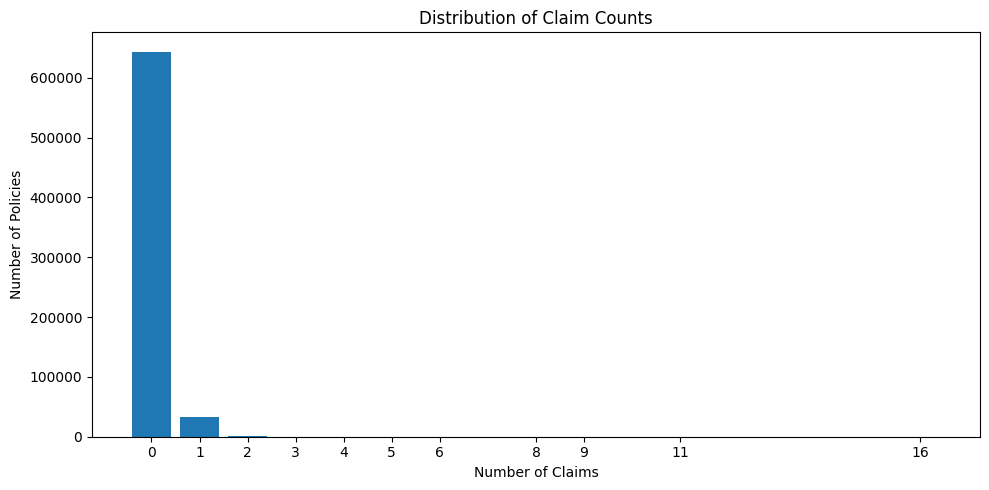

In [188]:
# Visualise Claim Frequency Distribution

plt.figure(figsize=(10, 5))

plt.bar(
    claim_distribution.index,
    claim_distribution.values
)

plt.title("Distribution of Claim Counts")

plt.xlabel("Number of Claims")

plt.ylabel("Number of Policies")

plt.xticks(claim_distribution.index)

plt.tight_layout()

plt.show()

### Business Interpretation

The claim frequency distribution shows that the majority of policyholders recorded no claims during the observation period, while progressively fewer policies generated one or more claims. This highly imbalanced pattern is typical of motor insurance portfolios.

### Pricing Implication

The dominance of zero-claim policies indicates that claim frequency modelling should account for sparse claim data. This supports the use of actuarial frequency models, such as Poisson or Negative Binomial regression, in the pricing stage.

## Analysis 3: Driver Age Distribution

### Business Question

How is the age of insured drivers distributed across the portfolio?

In [189]:
# Summary Statistics for Driver Age

frequency_data["DrivAge"].describe().round(2)

count   678,013.0000
mean         45.5000
std          14.1400
min          18.0000
25%          34.0000
50%          44.0000
75%          55.0000
max         100.0000
Name: DrivAge, dtype: float64

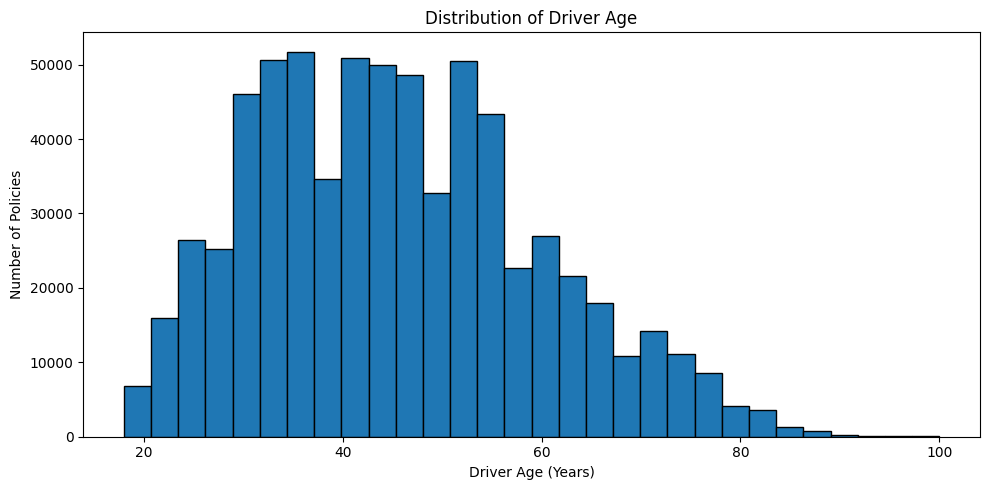

In [190]:
# Driver Age Distribution

plt.figure(figsize=(10, 5))

plt.hist(
    frequency_data["DrivAge"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Driver Age")

plt.xlabel("Driver Age (Years)")

plt.ylabel("Number of Policies")

plt.tight_layout()

plt.show()

### Business Interpretation

The portfolio contains **678,013** insured drivers with ages ranging from **18 to 100 years**. The average driver age is **45.5 years**, while the median age is **44 years**, indicating that the portfolio is primarily composed of middle-aged drivers.

The histogram shows that most policyholders fall between approximately **30 and 60 years** of age, with relatively few drivers at the youngest and oldest ends of the distribution. This suggests that the portfolio is concentrated in the working-age population, which is typical of many motor insurance portfolios.

No unusual spikes or implausible age values were observed, indicating that the driver age variable is suitable for further modelling.

### Pricing Implication

Driver age is an important rating factor in motor insurance because accident risk and driving experience often vary across different age groups. The observed distribution supports including driver age as a predictor in the pricing model. In later analyses, claim frequency and claim severity can be examined across different age groups to identify higher-risk segments and improve risk-based premium calculations.

## Analysis 4: Vehicle Age Distribution

### Business Question

How are vehicle ages distributed across the insured portfolio?

In [191]:
# Summary Statistics for Vehicle Age

frequency_data["VehAge"].describe().round(2)

count   678,013.0000
mean          7.0400
std           5.6700
min           0.0000
25%           2.0000
50%           6.0000
75%          11.0000
max         100.0000
Name: VehAge, dtype: float64

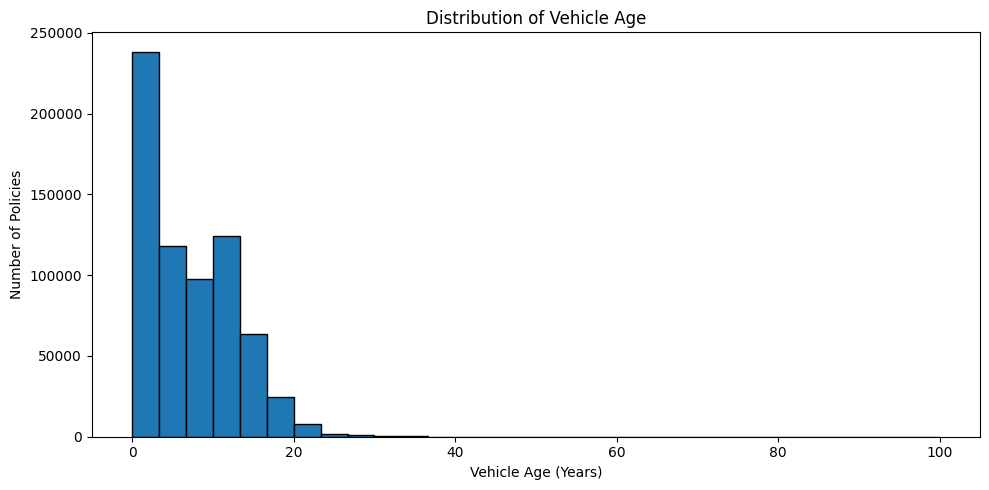

In [192]:
# Vehicle Age Distribution

plt.figure(figsize=(10, 5))

plt.hist(
    frequency_data["VehAge"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Vehicle Age")

plt.xlabel("Vehicle Age (Years)")

plt.ylabel("Number of Policies")

plt.tight_layout()

plt.show()

### Business Interpretation

The portfolio contains **678,013** insured vehicles with ages ranging from **0 to 100 years**. The average vehicle age is **7.04 years**, while the median age is **6 years**, indicating that most insured vehicles are relatively modern.

The distribution is positively skewed, with a large concentration of vehicles between **0 and 15 years** old. The number of insured vehicles decreases steadily as vehicle age increases, with only a small proportion of vehicles older than 20 years.

The presence of a small number of vehicles with ages approaching 100 years may represent rare classic or vintage vehicles. These observations warrant further investigation during modelling but do not necessarily indicate data quality issues.

### Pricing Implication

Vehicle age is an important rating factor in motor insurance because it can influence repair costs, reliability and the availability of replacement parts. The observed distribution supports including vehicle age as a predictor in the pricing model. Further analysis can examine whether claim frequency or claim severity varies across different vehicle age groups to improve premium estimation.

## Analysis 5: Bonus-Malus Distribution

### Business Question

How are Bonus-Malus scores distributed across the insured portfolio?

In [193]:
# Summary Statistics for Bonus-Malus

frequency_data["BonusMalus"].describe().round(2)

count   678,013.0000
mean         59.7600
std          15.6400
min          50.0000
25%          50.0000
50%          50.0000
75%          64.0000
max         230.0000
Name: BonusMalus, dtype: float64

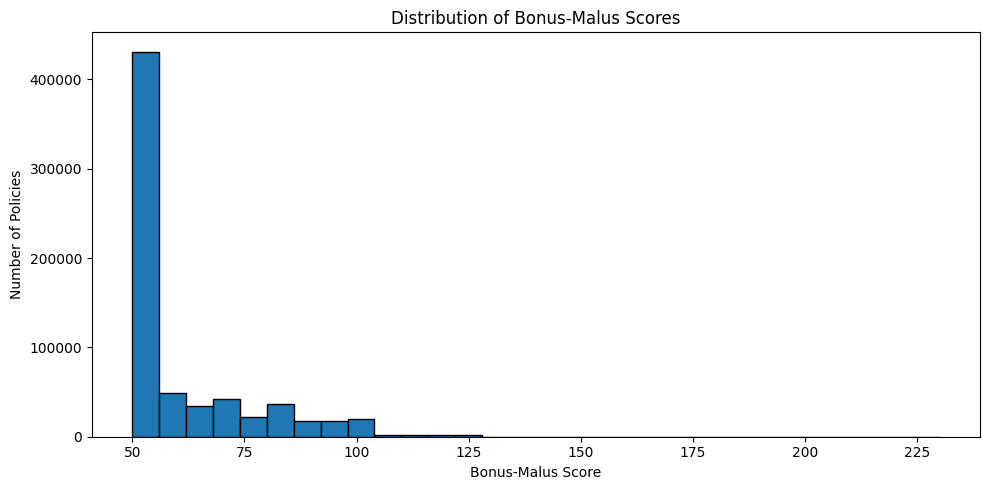

In [194]:
# Bonus-Malus Distribution

plt.figure(figsize=(10, 5))

plt.hist(
    frequency_data["BonusMalus"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Bonus-Malus Scores")

plt.xlabel("Bonus-Malus Score")

plt.ylabel("Number of Policies")

plt.tight_layout()

plt.show()

### Business Interpretation

The Bonus-Malus scores range from **50 to 230**, with an average score of **59.76** and a median score of **50**, indicating that at least half of the policyholders have the lowest Bonus-Malus score in the portfolio.

The distribution is highly right-skewed, with a large concentration of policyholders at a score of **50** and progressively fewer policyholders at higher scores. Only a small proportion of drivers have Bonus-Malus values above 100, indicating relatively few policyholders with poor claims histories.

This distribution suggests that the portfolio is largely composed of experienced drivers with favourable insurance records, while higher-risk drivers represent a much smaller segment of the insured population.

### Pricing Implication

Bonus-Malus is one of the strongest predictors of future claim behaviour because it reflects a policyholder's previous claims experience. Drivers with higher Bonus-Malus scores generally present greater insurance risk and are therefore more likely to attract higher premiums. The observed distribution supports the inclusion of Bonus-Malus as a key rating factor in the pricing model and suggests that it will contribute significantly to risk differentiation.

## Analysis 6: Vehicle Power Distribution

### Business Question

How is vehicle power distributed across the insured portfolio?

In [195]:
# Summary Statistics for Vehicle Power

frequency_data["VehPower"].describe().round(2)

count   678,013.0000
mean          6.4500
std           2.0500
min           4.0000
25%           5.0000
50%           6.0000
75%           7.0000
max          15.0000
Name: VehPower, dtype: float64

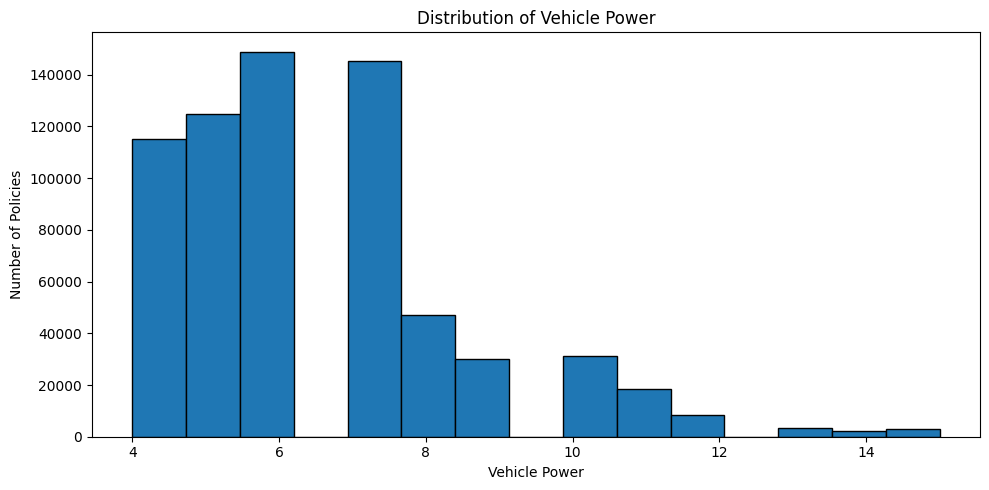

In [196]:
# Vehicle Power Distribution

plt.figure(figsize=(10, 5))

plt.hist(
    frequency_data["VehPower"],
    bins=15,
    edgecolor="black"
)

plt.title("Distribution of Vehicle Power")

plt.xlabel("Vehicle Power")

plt.ylabel("Number of Policies")

plt.tight_layout()

plt.show()

### Business Interpretation

The insured vehicles have power ratings ranging from **4 to 15**, with an average vehicle power of **6.45** and a median of **6**. The majority of vehicles are concentrated between power ratings **5 and 7**, indicating that the portfolio primarily consists of vehicles with moderate engine power.

Only a relatively small proportion of vehicles have power ratings above **10**, suggesting that high-performance vehicles represent a limited segment of the insured portfolio. Overall, the distribution indicates that the insurer's portfolio is dominated by standard passenger vehicles rather than high-powered or luxury vehicles.

### Pricing Implication

Vehicle power is an important underwriting factor because higher-powered vehicles are often associated with increased repair costs, higher market values and potentially greater accident severity. Including vehicle power in the pricing model allows insurers to differentiate premiums according to the level of vehicle-related risk and expected claim costs.

## Analysis 7: Fuel Type Distribution

### Business Question

How are fuel types distributed across the insured portfolio?

In [197]:
# Fuel Type Frequency

fuel_summary = (
    frequency_data["VehGas"]
    .value_counts()
    .rename_axis("Fuel Type")
    .reset_index(name="Number of Policies")
)

fuel_summary["Percentage (%)"] = (
    fuel_summary["Number of Policies"]
    / fuel_summary["Number of Policies"].sum()
    * 100
).round(2)

fuel_summary

,Fuel Type,Number of Policies,Percentage (%)
0,'Regular',345877,51.0100
1,'Diesel',332136,48.9900


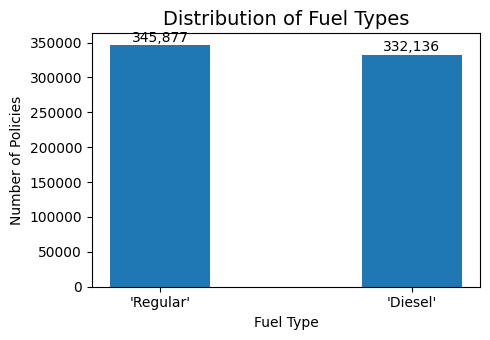

In [198]:
# Fuel Type Distribution

fuel_counts = frequency_data["VehGas"].value_counts()

plt.figure(figsize=(5, 3.5))

bars = plt.bar(
    fuel_counts.index,
    fuel_counts.values,
    width=0.4
)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 5000,
        f"{height:,}",
        ha="center",
        fontsize=10
    )

plt.title("Distribution of Fuel Types", fontsize=14)
plt.xlabel("Fuel Type")
plt.ylabel("Number of Policies")

plt.tight_layout()
plt.show()

### Business Interpretation

The portfolio is almost evenly divided between **Regular** and **Diesel** vehicles. Regular fuel vehicles account for **51.01%** of the insured portfolio, while Diesel vehicles represent **48.99%**.

This balanced distribution indicates that the insurer has a diversified portfolio with no single fuel type dominating the market. As a result, comparisons of claim experience between fuel types can be made without substantial concerns about class imbalance.

### Pricing Implication

Fuel type may influence insurance risk through differences in vehicle usage, annual mileage, maintenance costs and repair expenses. Including fuel type in the pricing model allows insurers to assess whether Regular and Diesel vehicles exhibit different claim frequencies or claim severities, supporting more accurate risk-based premium calculations.

## Analysis 8: Population Density Distribution

### Business Question

How is population density distributed across the insured portfolio?

In [199]:
# Summary Statistics for Population Density

frequency_data["Density"].describe().round(2)

count   678,013.0000
mean      1,792.4200
std       3,958.6500
min           1.0000
25%          92.0000
50%         393.0000
75%       1,658.0000
max      27,000.0000
Name: Density, dtype: float64

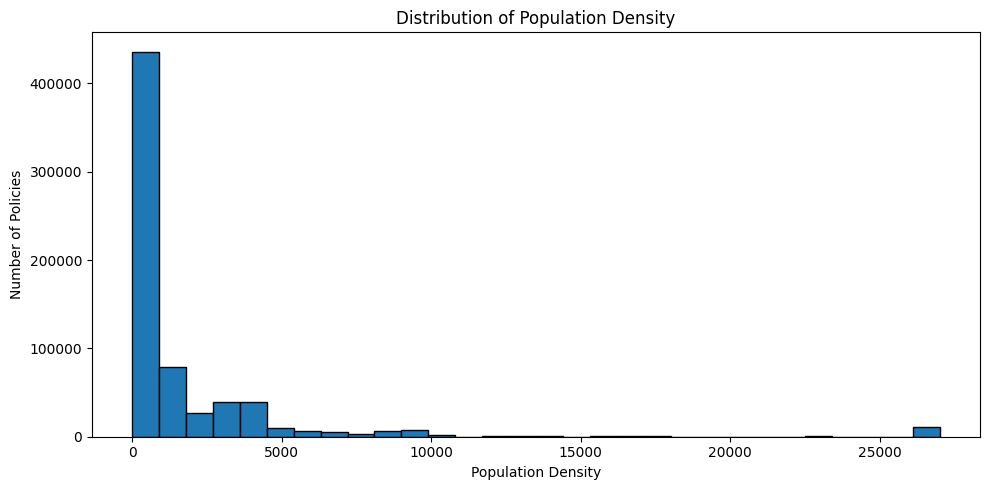

In [200]:
# Population Density Distribution

plt.figure(figsize=(10, 5))

plt.hist(
    frequency_data["Density"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Population Density")
plt.xlabel("Population Density")
plt.ylabel("Number of Policies")

plt.tight_layout()
plt.show()

### Business Interpretation

- Population density is strongly right-skewed.
- Most insured policies are located in low- to medium-density areas.
- A relatively small number of policies are concentrated in highly populated urban regions.
- The large gap between the mean (1,792) and median (393) confirms the presence of extreme high-density observations.
- Population density is an important pricing variable because urban areas generally experience heavier traffic, higher accident exposure, and increased claim frequency.

### Business Insight

The portfolio is predominantly composed of policies from lower-density regions, while a smaller proportion originates from densely populated urban locations. Population density should therefore be considered alongside driver and vehicle characteristics when developing predictive pricing models for claim frequency.

## Analysis 9: Regional Distribution

### Business Question

How are insurance policies distributed across different geographical regions?

In [201]:
# Regional Distribution

region_summary = (
    frequency_data["Region"]
    .value_counts()
    .rename_axis("Region")
    .reset_index(name="Number of Policies")
)

region_summary["Percentage (%)"] = (
    region_summary["Number of Policies"]
    / region_summary["Number of Policies"].sum()
    * 100
).round(2)

region_summary

,Region,Number of Policies,Percentage (%)
0,R24,160601,23.6900
1,R82,84752,12.5000
2,R93,79315,11.7000
3,R11,69791,10.2900
4,R53,42122,6.2100
5,R52,38751,5.7200
6,R91,35805,5.2800
7,R72,31329,4.6200
8,R31,27285,4.0200
9,R54,19046,2.8100


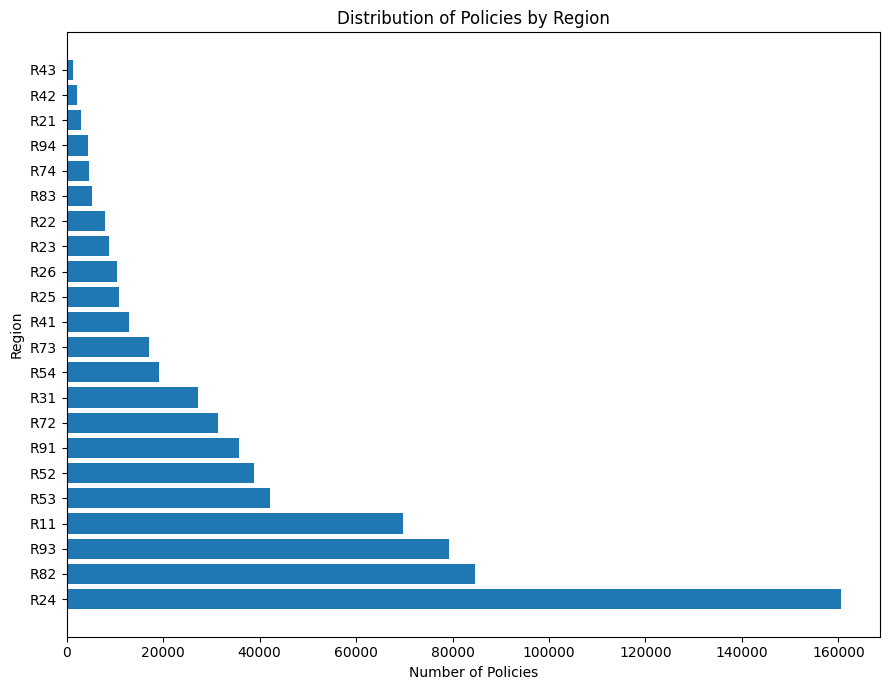

In [202]:
plt.figure(figsize=(9,7))

plt.barh(
    region_summary["Region"],
    region_summary["Number of Policies"]
)

plt.title("Distribution of Policies by Region")
plt.xlabel("Number of Policies")
plt.ylabel("Region")

plt.tight_layout()
plt.show()

### Business Interpretation

The insurance portfolio is unevenly distributed across geographical regions. Region **R24** contains the largest share of policies (23.69%), followed by **R82** (12.50%), **R93** (11.70%), and **R11** (10.29%). Together, these four regions account for more than half of the entire portfolio.

Several regions, including **R42**, **R43**, and **R21**, contribute less than 1% of the total policies, indicating relatively small market representation.

This concentration suggests that the insurer has a stronger presence in a limited number of regions, while maintaining a smaller exposure in many others.

### Business Insight

Regional concentration is an important consideration in insurance pricing and portfolio management. Geographic differences often reflect variations in traffic conditions, weather exposure, crime rates, repair costs, and claim behaviour.

The region variable is therefore expected to be a valuable predictor in claim frequency and pricing models and should be retained for further modelling.

## Analysis 10: Vehicle Brand Distribution

### Business Question

How are insurance policies distributed across different vehicle brands?

In [203]:
# Vehicle Brand Frequency

brand_summary = (
    frequency_data["VehBrand"]
    .value_counts()
    .rename_axis("Vehicle Brand")
    .reset_index(name="Number of Policies")
)

brand_summary["Percentage (%)"] = (
    brand_summary["Number of Policies"]
    / brand_summary["Number of Policies"].sum()
    * 100
).round(2)

brand_summary

,Vehicle Brand,Number of Policies,Percentage (%)
0,B12,166024,24.4900
1,B1,162736,24.0000
2,B2,159861,23.5800
3,B3,53395,7.8800
4,B5,34753,5.1300
5,B6,28548,4.2100
6,B4,25179,3.7100
7,B10,17707,2.6100
8,B11,13585,2.0000
9,B13,12178,1.8000


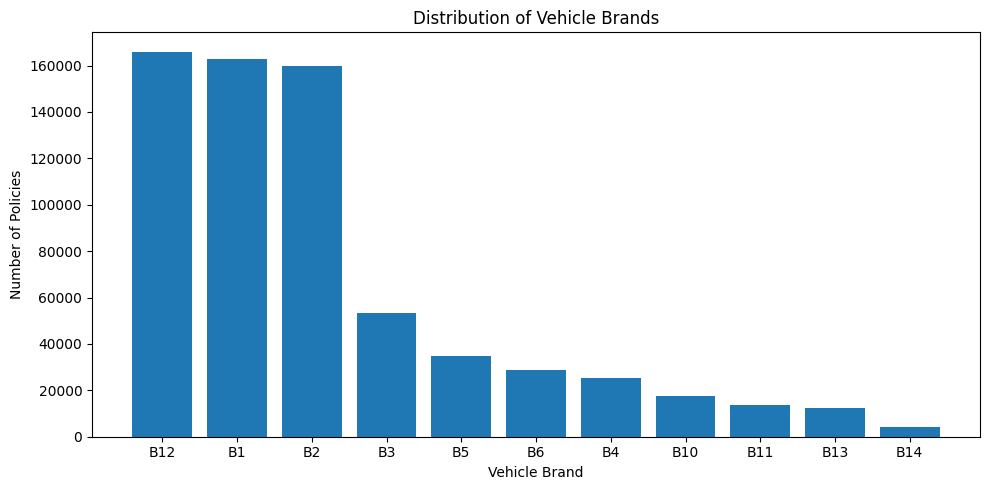

In [204]:
plt.figure(figsize=(10,5))

plt.bar(
    brand_summary["Vehicle Brand"],
    brand_summary["Number of Policies"]
)

plt.title("Distribution of Vehicle Brands")
plt.xlabel("Vehicle Brand")
plt.ylabel("Number of Policies")

plt.tight_layout()
plt.show()

### Business Interpretation

The insured portfolio is concentrated among a small number of vehicle brands. Brands **B12 (24.49%)**, **B1 (24.00%)**, and **B2 (23.58%)** together account for approximately **72%** of all insured vehicles, indicating that the portfolio is dominated by these three manufacturers.

The remaining brands have substantially lower representation. Brands **B3 (7.88%)**, **B5 (5.13%)**, and **B6 (4.21%)** form a secondary group, while several brands, including **B10**, **B11**, **B13**, and **B14**, each account for less than 3% of the portfolio.

This uneven distribution indicates that exposure is concentrated in a relatively small number of vehicle brands.

### Business Insight

Vehicle brand is an important rating factor in motor insurance because different manufacturers are associated with varying repair costs, vehicle values, theft rates, reliability, and claim experience.

The strong concentration of policies within a few vehicle brands suggests that these brands will contribute most significantly to the insurer's overall claims exposure. Consequently, vehicle brand should be retained as a key predictor when developing claim frequency and pricing models.

## Analysis 11: Area Distribution

### Business Question

How are insurance policies distributed across different geographical area categories?

In [205]:
# Area Frequency Table

area_summary = (
    frequency_data["Area"]
    .value_counts()
    .rename_axis("Area")
    .reset_index(name="Number of Policies")
)

area_summary["Percentage (%)"] = (
    area_summary["Number of Policies"]
    / area_summary["Number of Policies"].sum()
    * 100
).round(2)

area_summary

,Area,Number of Policies,Percentage (%)
0,C,191880,28.3000
1,D,151596,22.3600
2,E,137167,20.2300
3,A,103957,15.3300
4,B,75459,11.1300
5,F,17954,2.6500


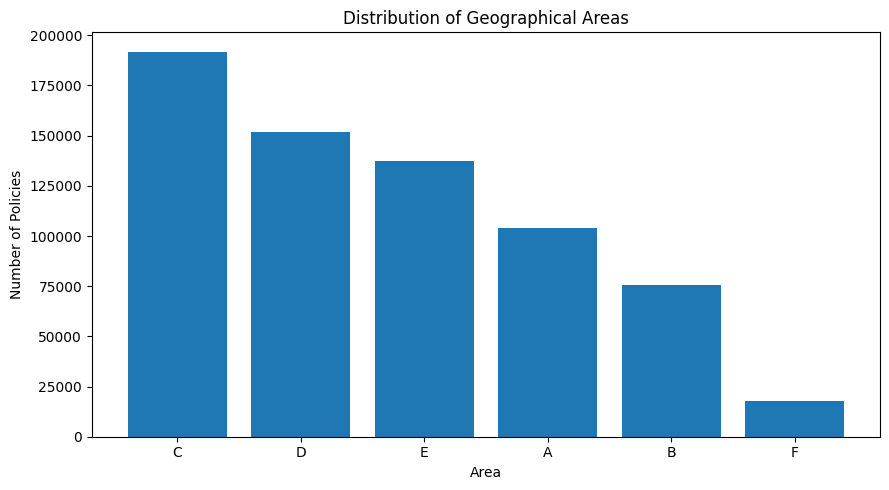

In [206]:
plt.figure(figsize=(9,5))

plt.bar(
    area_summary["Area"],
    area_summary["Number of Policies"]
)

plt.title("Distribution of Geographical Areas")
plt.xlabel("Area")
plt.ylabel("Number of Policies")

plt.tight_layout()
plt.show()

### Business Interpretation

The insured portfolio is concentrated in a few geographical area categories. Area C contains the largest share of policies (28.30%), followed by Areas D (22.36%) and E (20.23%). Together, these three areas account for more than 70% of the portfolio. Area F has the smallest representation at only 2.65%, indicating relatively low policy exposure in that location.

### Business Insight

The uneven geographical distribution suggests that insurers have greater exposure in Areas C, D and E. These locations should receive greater attention during pricing, risk monitoring and portfolio management, as changes in claim experience within these areas are likely to have the greatest impact on overall portfolio performance.

## Analysis 12: Policy Exposure Distribution

### Business Question

How is policy exposure distributed across the insured portfolio?

In [207]:
# Summary Statistics for Exposure

frequency_data["Exposure"].describe().round(2)

count   678,013.0000
mean          0.5300
std           0.3600
min           0.0000
25%           0.1800
50%           0.4900
75%           0.9900
max           2.0100
Name: Exposure, dtype: float64

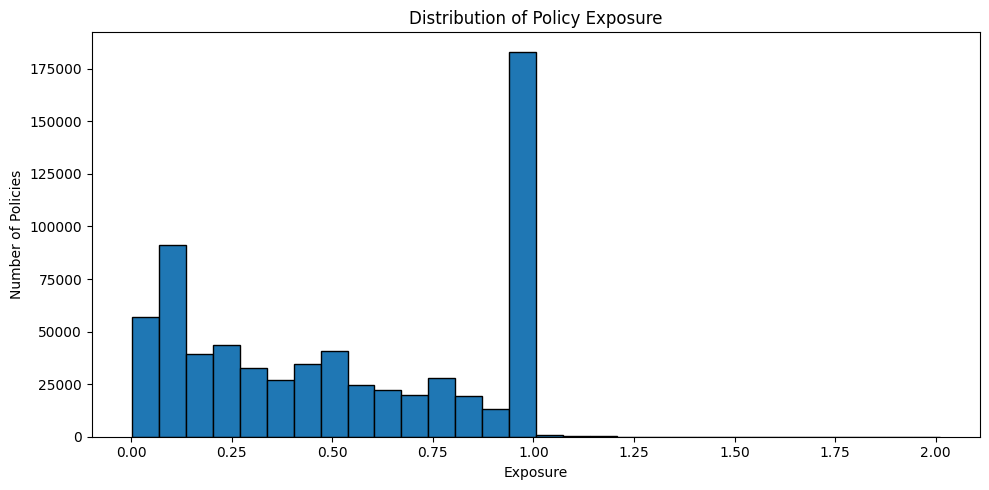

In [208]:
# Policy Exposure Distribution

plt.figure(figsize=(10, 5))

plt.hist(
    frequency_data["Exposure"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribution of Policy Exposure")
plt.xlabel("Exposure")
plt.ylabel("Number of Policies")

plt.tight_layout()
plt.show()

### Business Interpretation

Policy exposure is concentrated around one year, indicating that most policies remained active for the majority of the observation period. However, the portfolio also contains a substantial number of policies with partial exposure, reflecting policies that were initiated, cancelled or terminated before completing a full year. A small number of observations exceed one year of exposure, suggesting extended coverage periods or renewals within the observation window.

### Business Insight

The presence of varying exposure periods highlights the importance of adjusting claim frequency calculations for the actual time each policy was at risk. Using exposure rather than simple policy counts ensures fair comparisons across policyholders and produces more accurate actuarial pricing models.

### Analysis 1: Driver Age vs Claim Frequency

### Business Question

How does driver age influence claim frequency across the insured portfolio?

In [209]:
# Create Driver Age Groups

frequency_data["DriverAgeGroup"] = pd.cut(
    frequency_data["DrivAge"],
    bins=[18, 25, 35, 45, 55, 65, 100],
    labels=[
        "18-25",
        "26-35",
        "36-45",
        "46-55",
        "56-65",
        "65+"
    ],
    include_lowest=True
)

In [210]:
# Average Claim Frequency by Driver Age Group

driver_age_summary = (
    frequency_data
    .groupby("DriverAgeGroup", observed=True)
    .agg(
        Average_Claim_Frequency=("ClaimNb", "mean"),
        Number_of_Policies=("ClaimNb", "count")
    )
    .reset_index()
)

driver_age_summary

,DriverAgeGroup,Average_Claim_Frequency,Number_of_Policies
0,18-25,0.0730,38895
1,26-35,0.0447,149183
2,36-45,0.0493,170352
3,46-55,0.0572,161899
4,56-65,0.0524,90691
5,65+,0.0627,66993


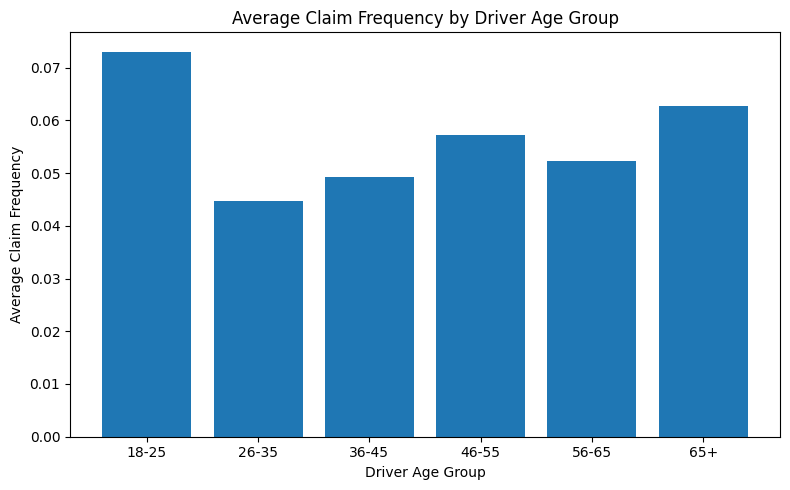

In [211]:
plt.figure(figsize=(8,5))

plt.bar(
    driver_age_summary["DriverAgeGroup"],
    driver_age_summary["Average_Claim_Frequency"]
)

plt.title("Average Claim Frequency by Driver Age Group")
plt.xlabel("Driver Age Group")
plt.ylabel("Average Claim Frequency")

plt.tight_layout()
plt.show()

### Business Interpretation
Drivers aged 18–25 have the highest average claim frequency (0.073), suggesting that younger drivers present the greatest insurance risk.
Claim frequency falls sharply for the 26–35 age group, which appears to be the lowest-risk segment.
Risk gradually increases again from middle age onwards.
Drivers aged 65+ also exhibit relatively high claim frequencies, although still below the youngest group.
Overall, the relationship forms a U-shaped pattern, where both the youngest and oldest drivers tend to generate more claims than middle-aged drivers.

### Business Insight

The results help insurers evaluate whether vehicle age should be incorporated as a pricing factor. If older vehicles exhibit higher claim frequencies, insurers may adjust premiums accordingly or apply additional underwriting considerations for high-risk vehicle segments.

### Analysis 2: Vehicle Age vs Claim Frequency
Business Question

How does vehicle age influence average claim frequency?

In [212]:
# Create Vehicle Age Groups

frequency_data["VehicleAgeGroup"] = pd.cut(
    frequency_data["VehAge"],
    bins=[-1, 2, 5, 10, 15, 20, 100],
    labels=[
        "0-2",
        "3-5",
        "6-10",
        "11-15",
        "16-20",
        "20+"
    ]
)

In [213]:
vehicle_age_summary = (
    frequency_data
    .groupby("VehicleAgeGroup", observed=True)
    .agg(
        Average_Claim_Frequency=("ClaimNb", "mean"),
        Number_of_Policies=("ClaimNb", "count")
    )
    .reset_index()
)

vehicle_age_summary

,VehicleAgeGroup,Average_Claim_Frequency,Number_of_Policies
0,0-2,0.0580,188147
1,3-5,0.0509,132490
2,6-10,0.0574,171594
3,11-15,0.0496,134063
4,16-20,0.0388,43397
5,20+,0.0332,8322


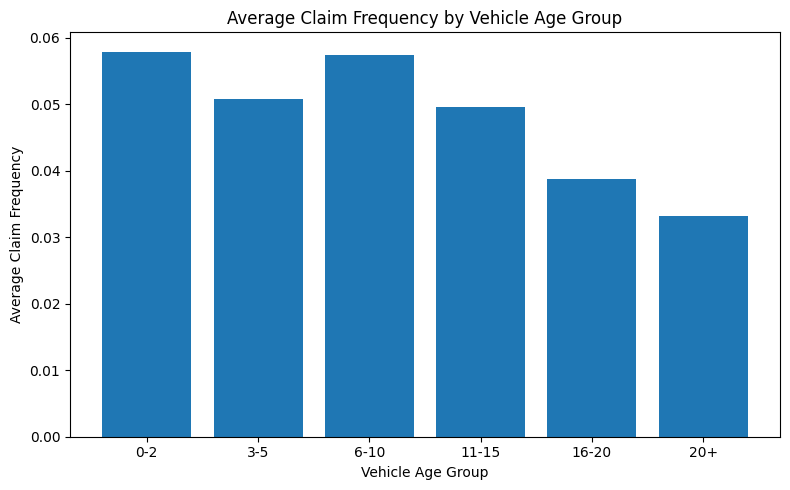

In [214]:
plt.figure(figsize=(8,5))

plt.bar(
    vehicle_age_summary["VehicleAgeGroup"],
    vehicle_age_summary["Average_Claim_Frequency"]
)

plt.title("Average Claim Frequency by Vehicle Age Group")
plt.xlabel("Vehicle Age Group")
plt.ylabel("Average Claim Frequency")

plt.tight_layout()

plt.show()

### Business Interpretation

This analysis examines the relationship between vehicle age and average claim frequency. The results indicate that newer vehicles (0–2 years) and vehicles aged 6–10 years have the highest average claim frequencies, while claim frequency gradually declines as vehicles become older. Vehicles aged over 20 years exhibit the lowest average claim frequency in the portfolio.

### Business Insight

Vehicle age appears to be an important predictor of claim frequency, although the relationship is not strictly linear. The findings suggest that insurers should consider vehicle age alongside other rating factors, such as driver age, policy exposure, and vehicle characteristics, when developing pricing models. Newer and mid-aged vehicles may require closer risk assessment due to their relatively higher claim frequencies.

### Business Question

How does the Bonus-Malus score relate to claim frequency?

In [215]:
# Create Bonus-Malus Groups

frequency_data["BonusMalusGroup"] = pd.cut(
    frequency_data["BonusMalus"],
    bins=[0, 50, 75, 100, 125, 150, 200],
    labels=["0-50", "51-75", "76-100", "101-125", "126-150", "150+"],
    include_lowest=True
)

In [216]:
bonus_summary = (
    frequency_data
    .groupby("BonusMalusGroup", observed=True)
    .agg(
        Average_Claim_Frequency=("ClaimNb", "mean"),
        Number_of_Policies=("ClaimNb", "count")
    )
    .reset_index()
)

bonus_summary

,BonusMalusGroup,Average_Claim_Frequency,Number_of_Policies
0,0-50,0.0470,384156
1,51-75,0.0549,175012
2,76-100,0.0638,111051
3,101-125,0.1686,6987
4,126-150,0.1839,598
5,150+,0.2537,205


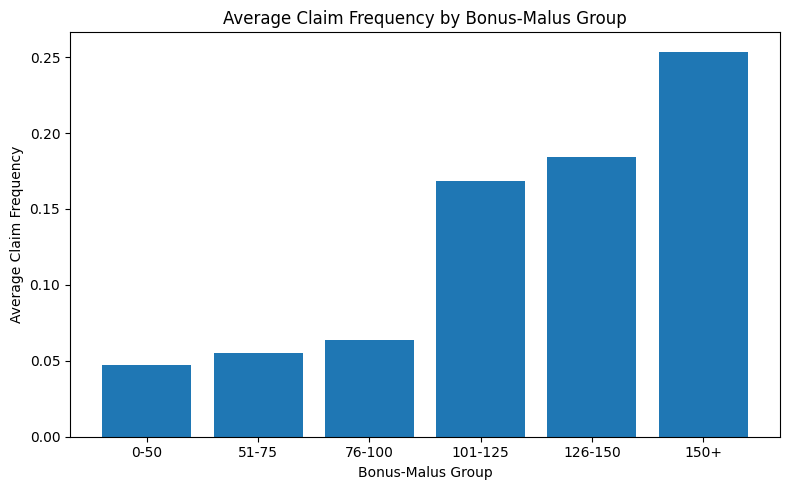

In [217]:
plt.figure(figsize=(8,5))

plt.bar(
    bonus_summary["BonusMalusGroup"],
    bonus_summary["Average_Claim_Frequency"]
)

plt.title("Average Claim Frequency by Bonus-Malus Group")
plt.xlabel("Bonus-Malus Group")
plt.ylabel("Average Claim Frequency")

plt.tight_layout()
plt.show()

### Business Interpretation

The analysis reveals a strong positive relationship between the Bonus-Malus score and average claim frequency. Policyholders with lower Bonus-Malus scores (0–50) have the lowest average claim frequency (0.0470), while those with the highest scores (150+) record the highest average claim frequency (0.2537). Although the highest Bonus-Malus categories contain relatively few policyholders, they consistently exhibit substantially higher claim frequencies than the rest of the portfolio. This demonstrates that historical driving performance, as reflected by the Bonus-Malus system, is a strong indicator of future claim risk.

### Business Insight

The Bonus-Malus score is a highly predictive risk variable and should remain a key component of pricing and underwriting models. Drivers with high Bonus-Malus scores present significantly greater claim risk and therefore justify higher premiums or closer underwriting review. Conversely, policyholders with low Bonus-Malus scores demonstrate consistently lower claim frequencies, supporting premium discounts and customer retention strategies for low-risk drivers.

### Business Question

How does vehicle power influence claim frequency?

In [218]:
# Create Vehicle Power Groups

frequency_data["VehiclePowerGroup"] = pd.cut(
    frequency_data["VehPower"],
    bins=[0, 5, 7, 9, 20],
    labels=["Low (0-5)", "Medium (6-7)", "High (8-9)", "Very High (10+)"],
    include_lowest=True
)

In [219]:
power_summary = (
    frequency_data
    .groupby("VehiclePowerGroup", observed=True)
    .agg(
        Average_Claim_Frequency=("ClaimNb", "mean"),
        Number_of_Policies=("ClaimNb", "count")
    )
    .reset_index()
)

power_summary

,VehiclePowerGroup,Average_Claim_Frequency,Number_of_Policies
0,Low (0-5),0.0540,240170
1,Medium (6-7),0.0544,294377
2,High (8-9),0.0477,77041
3,Very High (10+),0.0518,66425


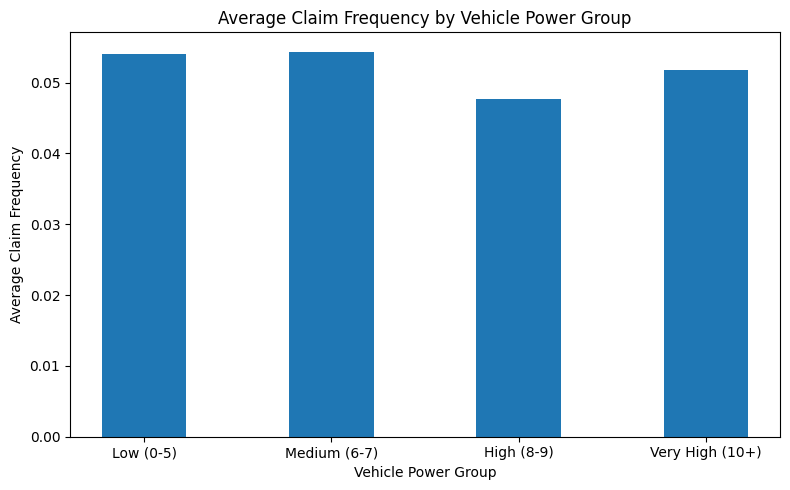

In [220]:
plt.figure(figsize=(8,5))

plt.bar(
    power_summary["VehiclePowerGroup"],
    power_summary["Average_Claim_Frequency"],
    width=0.45
)

plt.title("Average Claim Frequency by Vehicle Power Group")
plt.xlabel("Vehicle Power Group")
plt.ylabel("Average Claim Frequency")

plt.tight_layout()
plt.show()

### Business Interpretation

Average claim frequency is relatively similar across all vehicle power groups. Medium-powered vehicles (6–7 horsepower group) have the highest average claim frequency, while high-powered vehicles (8–9 horsepower group) have the lowest. The differences between groups are modest, indicating that vehicle power alone is not a strong predictor of claim frequency.

### Business Insight

Vehicle power appears to have only a limited influence on claim frequency within this portfolio. Although slight differences exist, they are not substantial enough to justify pricing decisions based solely on vehicle power. Vehicle power should therefore be combined with other risk factors such as driver age, Bonus-Malus score, vehicle age, and geographical area when developing predictive pricing models.

### Business Question

Does vehicle fuel type influence claim frequency?

In [221]:
# Create Fuel Type Groups Summary

fuel_summary = (
    frequency_data
    .groupby("VehGas", observed=True)
    .agg(
        Average_Claim_Frequency=("ClaimNb", "mean"),
        Number_of_Policies=("ClaimNb", "count")
    )
    .reset_index()
)

fuel_summary

,VehGas,Average_Claim_Frequency,Number_of_Policies
0,'Diesel',0.0501,332136
1,'Regular',0.0562,345877


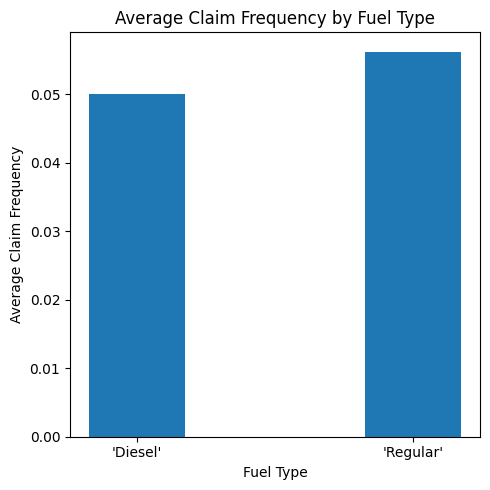

In [222]:
plt.figure(figsize=(5,5))

plt.bar(
    fuel_summary["VehGas"],
    fuel_summary["Average_Claim_Frequency"],
    width=0.35
)

plt.title("Average Claim Frequency by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Average Claim Frequency")

plt.tight_layout()
plt.show()

### Business Interpretation

Vehicles using regular fuel have a slightly higher average claim frequency (5.62%) than diesel-powered vehicles (5.01%). However, the difference between the two fuel types is relatively small, indicating that fuel type has only a modest relationship with claim frequency.

### Business Insight

Fuel type alone is not a strong predictor of insurance claims within this portfolio. While regular-fuel vehicles exhibit a marginally higher claim frequency, the difference is not substantial enough to justify pricing decisions based solely on fuel type. Fuel type should therefore be considered alongside other important risk factors such as driver age, Bonus-Malus score, vehicle age, and geographical region.

### Business Question

How does average claim frequency vary across different geographical regions?

In [223]:
# Create Region Summary

region_claim_summary = (
    frequency_data
    .groupby("Region", observed=True)
    .agg(
        Average_Claim_Frequency=("ClaimNb", "mean"),
        Number_of_Policies=("ClaimNb", "count")
    )
    .sort_values("Average_Claim_Frequency", ascending=False)
    .reset_index()
)

region_claim_summary

,Region,Average_Claim_Frequency,Number_of_Policies
0,R53,0.0641,42122
1,R42,0.0605,2200
2,R82,0.0594,84752
3,R25,0.0581,10893
4,R24,0.0573,160601
5,R11,0.0570,69791
6,R74,0.0567,4567
7,R22,0.0549,7994
8,R94,0.0547,4516
9,R21,0.0529,3026


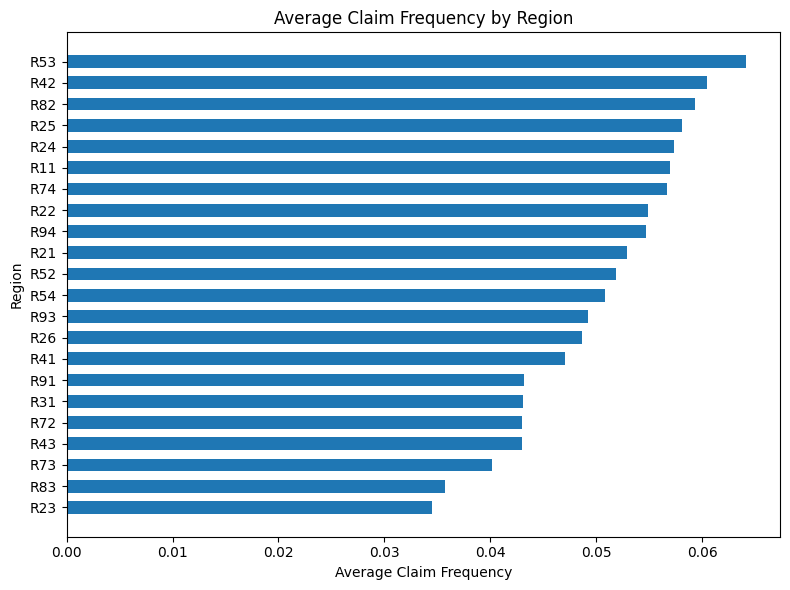

In [224]:
plt.figure(figsize=(8,6))

plt.barh(
    region_claim_summary["Region"],
    region_claim_summary["Average_Claim_Frequency"],
    height=0.6
)

plt.title("Average Claim Frequency by Region")
plt.xlabel("Average Claim Frequency")
plt.ylabel("Region")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

### Business Interpretation

Average claim frequency varies across geographical regions, although the differences are relatively modest. Region R53 records the highest average claim frequency (approximately 6.4%), followed by R42 and R82. Conversely, Regions R83 and R23 have the lowest average claim frequencies at approximately 3.6% and 3.5%, respectively.

Most regions fall within a relatively narrow claim frequency range of approximately 4% to 6%, indicating that regional location has some influence on insurance risk but is not the dominant predictor of claim occurrence.

### Business Insight

Regional differences suggest that geographical location contributes to claim risk, potentially reflecting variations in traffic density, road conditions, weather, driver behaviour, or local driving environments. However, because the variation between regions is relatively small, region should be considered alongside other risk factors such as driver age, vehicle age, Bonus-Malus score, and exposure when developing pricing models.

These findings support the inclusion of geographical region as one of several predictive variables rather than relying on it as a primary rating factor.

### Business Question

Does population density influence claim frequency?

In [225]:
frequency_data["DensityGroup"] = pd.qcut(
    frequency_data["Density"],
    q=5,
    labels=[
        "Very Low",
        "Low",
        "Medium",
        "High",
        "Very High"
    ]
)

In [226]:
density_summary = (
    frequency_data
    .groupby("DensityGroup", observed=True)
    .agg(
        Average_Claim_Frequency=("ClaimNb", "mean"),
        Number_of_Policies=("ClaimNb", "count")
    )
    .reset_index()
)

density_summary

,DensityGroup,Average_Claim_Frequency,Number_of_Policies
0,Very Low,0.0492,137340
1,Low,0.0503,134178
2,Medium,0.0524,135398
3,High,0.0570,137845
4,Very High,0.0575,133252


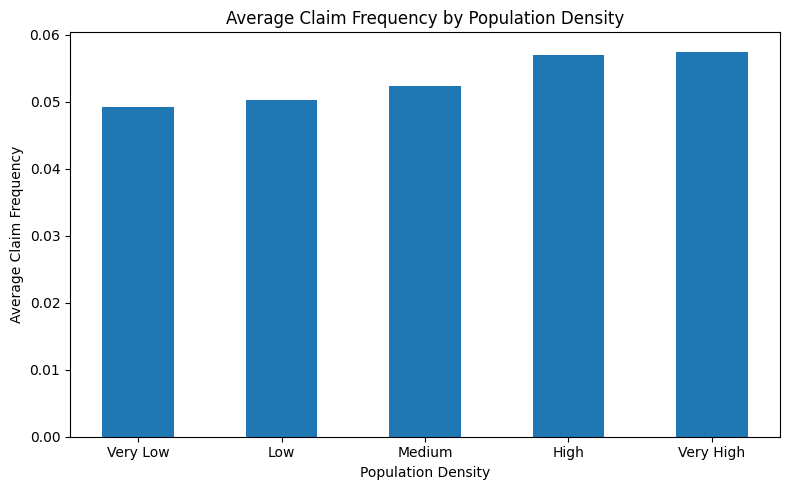

In [227]:
plt.figure(figsize=(8,5))

plt.bar(
    density_summary["DensityGroup"],
    density_summary["Average_Claim_Frequency"],
    width=0.5
)

plt.title("Average Claim Frequency by Population Density")
plt.xlabel("Population Density")
plt.ylabel("Average Claim Frequency")

plt.tight_layout()
plt.show()

### Business Interpretation

Average claim frequency increases progressively as population density rises. Policies located in areas with very low population density have the lowest average claim frequency (approximately 4.9%), while policies in very high-density areas experience the highest average claim frequency (approximately 5.8%).

The increase is gradual across the five density groups, indicating a positive relationship between population density and claim frequency.

### Business Insight

Higher population density is associated with a greater likelihood of insurance claims, likely due to increased traffic congestion, more frequent vehicle interactions, and a higher probability of collisions in urban environments. Although the increase in claim frequency is moderate, the consistent upward trend suggests that population density is a valuable predictor of insurance risk.

This variable should therefore be retained as an important feature within predictive pricing models and considered alongside other factors such as driver age, vehicle characteristics, Bonus-Malus score, exposure, and geographical region when assessing policy risk.

### Business Question

How do vehicle brand and fuel type interact to influence claim frequency?

In [228]:
brand_fuel_summary = frequency_data.pivot_table(
    values="ClaimNb",
    index="VehBrand",
    columns="VehGas",
    aggfunc="mean"
)

brand_fuel_summary

VehGas,'Diesel','Regular'
VehBrand,,
B1,0.0521,0.0544
B10,0.0508,0.0419
B11,0.0532,0.0530
B12,0.0407,0.0639
B13,0.0565,0.0501
B14,0.0500,0.0368
B2,0.0534,0.0538
B3,0.0527,0.0529
B4,0.0516,0.0525


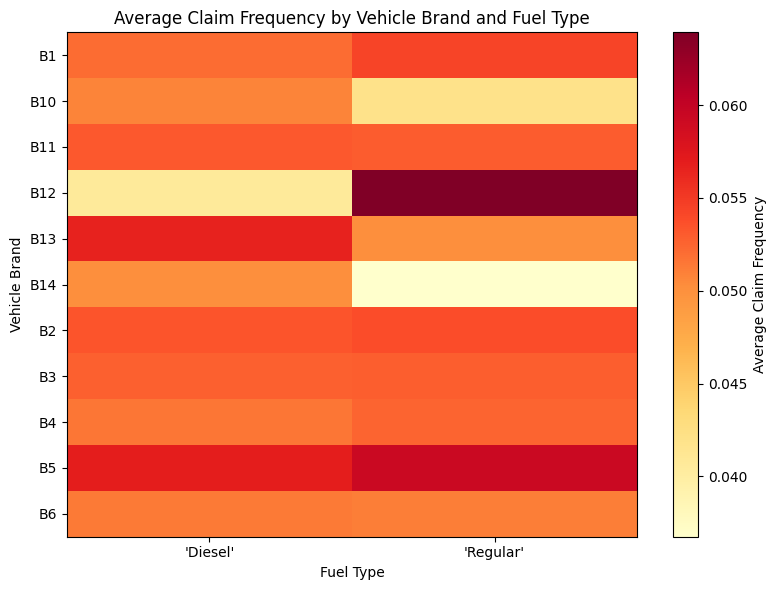

In [229]:
plt.figure(figsize=(8,6))

plt.imshow(
    brand_fuel_summary,
    aspect="auto",
    cmap="YlOrRd"
)

plt.colorbar(label="Average Claim Frequency")

plt.xticks(
    range(len(brand_fuel_summary.columns)),
    brand_fuel_summary.columns
)

plt.yticks(
    range(len(brand_fuel_summary.index)),
    brand_fuel_summary.index
)

plt.title("Average Claim Frequency by Vehicle Brand and Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Vehicle Brand")

plt.tight_layout()
plt.show()

### Business Interpretation

The interaction between vehicle brand and fuel type reveals that claim frequency varies across different combinations of these two variables. While most vehicle brands exhibit relatively similar claim frequencies between diesel and regular fuel vehicles, certain brands show more noticeable differences.

For example, Brand B12 records a considerably higher claim frequency for regular fuel vehicles (approximately 6.4%) than for diesel vehicles (approximately 4.1%). Conversely, Brand B10 and Brand B14 display lower claim frequencies for regular fuel vehicles compared with their diesel counterparts. Most other brands exhibit only small differences between fuel types.

Overall, the results suggest that the effect of fuel type on claim frequency is not consistent across all vehicle brands.

### Business Insight

The relationship between fuel type and claim frequency depends on the vehicle brand, indicating the presence of an interaction effect between these variables. This suggests that insurers should avoid assuming that fuel type has a uniform impact on risk across all vehicle manufacturers.

Although the differences are generally modest, modelling vehicle brand and fuel type together may improve predictive performance compared with considering each variable independently. These findings support the inclusion of interaction effects in more advanced pricing models such as Generalised Linear Models (GLMs) or machine learning algorithms.

## Analysis 22: Correlation Analysis of Numerical Variables

### Business Question

Which numerical variables have the strongest linear relationships with claim count?

In [230]:
# Select numerical variables for correlation analysis

correlation_variables = [
    "ClaimNb",
    "Exposure",
    "VehPower",
    "VehAge",
    "DrivAge",
    "BonusMalus",
    "Density"
]

correlation_data = frequency_data[correlation_variables]

In [231]:
# Calculate Pearson correlation matrix

correlation_matrix = correlation_data.corr().round(3)

correlation_matrix

,ClaimNb,Exposure,VehPower,VehAge,DrivAge,BonusMalus,Density
ClaimNb,1.0000,0.0690,-0.0040,-0.0220,0.0110,0.0510,0.0110
Exposure,0.0690,1.0000,-0.0450,0.1520,0.1720,-0.1830,-0.0710
VehPower,-0.0040,-0.0450,1.0000,-0.0060,0.0300,-0.0760,0.0430
VehAge,-0.0220,0.1520,-0.0060,1.0000,-0.0590,0.0800,-0.0900
DrivAge,0.0110,0.1720,0.0300,-0.0590,1.0000,-0.4800,-0.0050
BonusMalus,0.0510,-0.1830,-0.0760,0.0800,-0.4800,1.0000,0.0780
Density,0.0110,-0.0710,0.0430,-0.0900,-0.0050,0.0780,1.0000


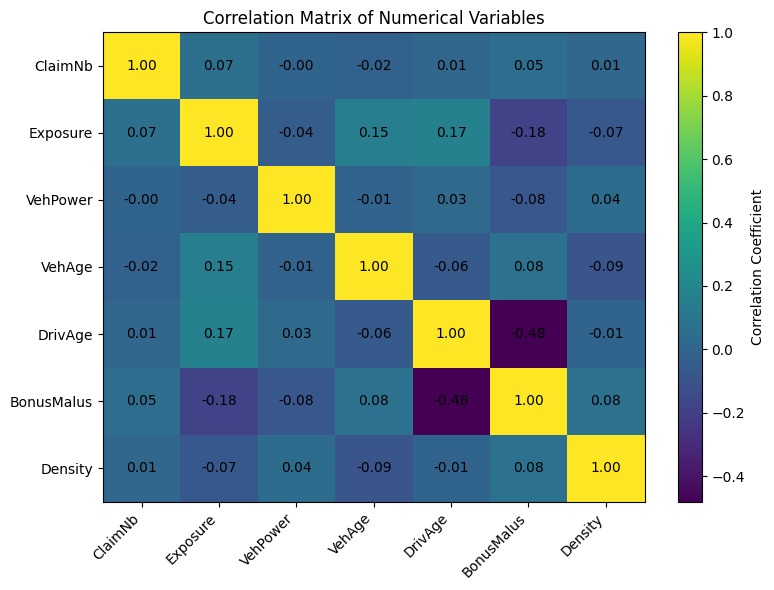

In [232]:
# Correlation Heatmap

plt.figure(figsize=(8, 6))

heatmap = plt.imshow(
    correlation_matrix,
    aspect="auto"
)

plt.colorbar(
    heatmap,
    label="Correlation Coefficient"
)

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation_matrix.index)),
    correlation_matrix.index
)

# Display correlation values inside the heatmap
for row in range(len(correlation_matrix.index)):
    for column in range(len(correlation_matrix.columns)):
        plt.text(
            column,
            row,
            f"{correlation_matrix.iloc[row, column]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Correlation Matrix of Numerical Variables")

plt.tight_layout()
plt.show()

### Business Interpretation

The correlation analysis shows that most numerical variables have only weak linear relationships with claim count. Exposure has the strongest positive correlation with `ClaimNb` at approximately 0.07, followed by Bonus-Malus at approximately 0.05. Vehicle power, vehicle age, driver age, and population density all have correlations close to zero with claim count.

The strongest relationship in the matrix is the negative correlation between driver age and Bonus-Malus, at approximately -0.48. This indicates that older drivers generally tend to have lower Bonus-Malus scores. Exposure also has modest positive relationships with vehicle age and driver age, and a modest negative relationship with Bonus-Malus.

### Business Insight

The weak correlations with claim count suggest that insurance risk is not adequately explained by simple linear relationships between individual numerical variables. Variables such as driver age, vehicle age, Bonus-Malus, and population density may still be important predictors, but their effects are likely to be non-linear, categorical, or dependent on interactions with other risk factors.

These findings support the use of Generalised Linear Models and appropriate feature engineering rather than relying on ordinary linear correlation alone. The moderate correlation between driver age and Bonus-Malus should also be monitored during modelling because it may introduce some overlap in the information provided by these variables.

## Analysis 23: Average Claim Frequency by Area

### Business Question

Does the geographical area where a policyholder lives influence claim frequency?

In [233]:
# Create Area Summary

area_summary = (
    frequency_data
    .groupby("Area", observed=True)
    .agg(
        Average_Claim_Frequency=("ClaimNb", "mean"),
        Number_of_Policies=("ClaimNb", "count")
    )
    .reset_index()
)

area_summary

,Area,Average_Claim_Frequency,Number_of_Policies
0,A,0.0487,103957
1,B,0.0504,75459
2,C,0.0515,191880
3,D,0.0556,151596
4,E,0.0569,137167
5,F,0.0630,17954


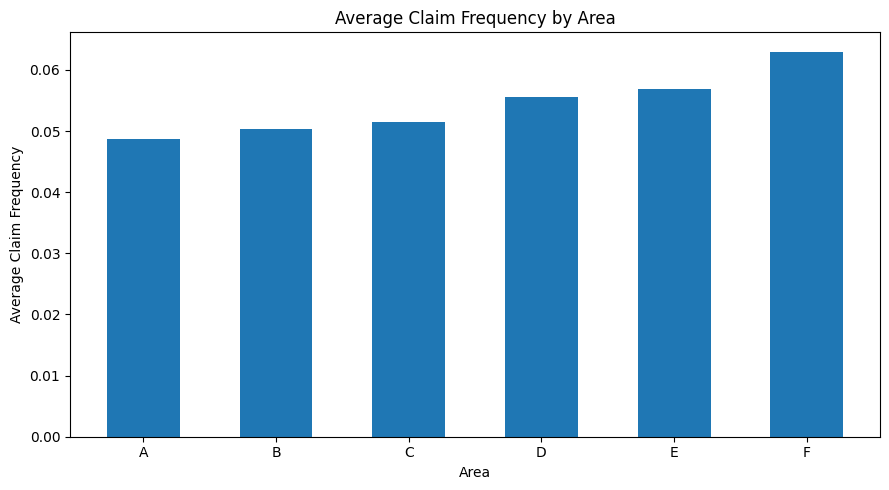

In [234]:
plt.figure(figsize=(9,5))

plt.bar(
    area_summary["Area"],
    area_summary["Average_Claim_Frequency"],
    width=0.55
)

plt.title("Average Claim Frequency by Area")
plt.xlabel("Area")
plt.ylabel("Average Claim Frequency")

plt.tight_layout()
plt.show()

### Business Interpretation

Average claim frequency increases progressively across Areas A to F. Area A records the lowest average claim frequency (4.87%), while Area F records the highest (6.30%). Although Areas A to E contain substantially larger numbers of policies, Area F exhibits the greatest claim frequency despite representing the smallest portfolio. This suggests that geographical location is associated with differences in claim risk.

### Business Insight

The results indicate that geographical area is an important predictor of insurance claim frequency. Policyholders located in Area F appear to be considerably more likely to submit claims than those in Areas A to C. This variable should therefore be considered during premium rating and risk segmentation, allowing insurers to better align premiums with regional risk exposure while improving pricing accuracy and portfolio management.

### Business Question

How do driver age and vehicle age interact to influence insurance claim frequency?

In [235]:
# Driver Age vs Vehicle Age Interaction

driver_vehicle_summary = frequency_data.pivot_table(
    values="ClaimNb",
    index="DriverAgeGroup",
    columns="VehicleAgeGroup",
    aggfunc="mean"
)

driver_vehicle_summary

VehicleAgeGroup,0-2,3-5,6-10,11-15,16-20,20+
DriverAgeGroup,,,,,,
18-25,0.0671,0.0716,0.0832,0.0712,0.0580,0.0608
26-35,0.0544,0.0419,0.0471,0.0363,0.0330,0.0249
36-45,0.0567,0.0481,0.0521,0.0440,0.0337,0.0272
46-55,0.0622,0.0533,0.0606,0.0559,0.0416,0.0331
56-65,0.0537,0.0508,0.0575,0.0522,0.0371,0.0290
65+,0.0601,0.0617,0.0720,0.0632,0.0468,0.0502


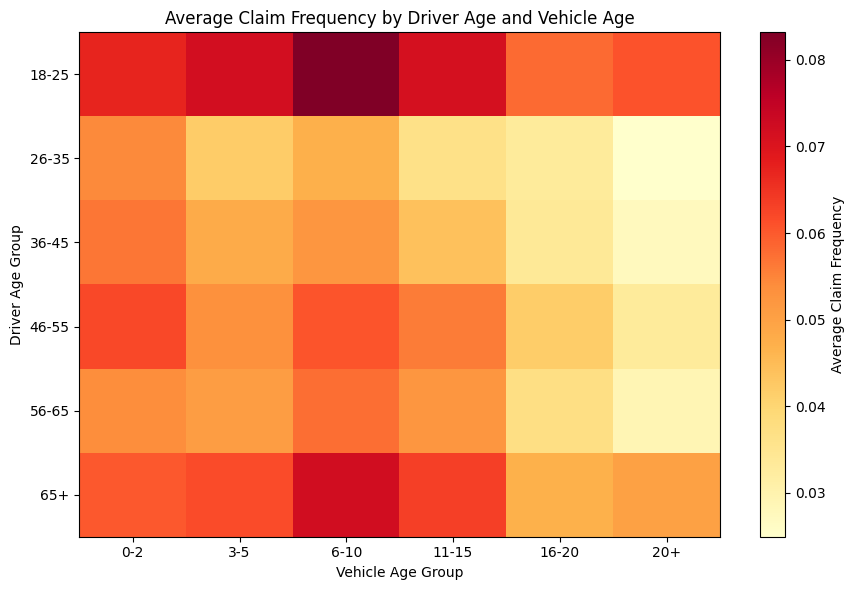

In [236]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9,6))

plt.imshow(driver_vehicle_summary, aspect="auto", cmap="YlOrRd")

plt.colorbar(label="Average Claim Frequency")

plt.xticks(
    range(len(driver_vehicle_summary.columns)),
    driver_vehicle_summary.columns
)

plt.yticks(
    range(len(driver_vehicle_summary.index)),
    driver_vehicle_summary.index
)

plt.xlabel("Vehicle Age Group")
plt.ylabel("Driver Age Group")
plt.title("Average Claim Frequency by Driver Age and Vehicle Age")

plt.tight_layout()
plt.show()

### Business Interpretation

The interaction between driver age and vehicle age reveals clear differences in claim frequency across policyholder groups. Drivers aged 18–25 consistently exhibit the highest claim frequencies across almost all vehicle age categories, with the highest observed claim frequency (8.32%) occurring among young drivers operating vehicles aged 6–10 years.

Across every driver age group, claim frequency generally decreases as vehicle age increases, particularly for vehicles older than 15 years. Middle-aged drivers (26–65) display relatively lower claim frequencies regardless of vehicle age, while drivers aged 65+ show moderately elevated claim frequencies compared with middle-aged drivers but remain below the youngest driver group.

### Business Insight

The results demonstrate that driver age and vehicle age jointly influence insurance claim frequency. Younger drivers consistently present the highest level of claim risk, particularly when driving moderately aged vehicles. This suggests that pricing models should consider interaction effects between driver characteristics and vehicle characteristics rather than evaluating each variable independently. Including these interaction effects in predictive pricing models can improve premium accuracy, strengthen risk segmentation, and support fairer underwriting decisions.

### Business Question

Which variables should be included in the predictive model for estimating motor insurance claim frequency?

In [237]:
# Create modelling dataset

model_data = frequency_data[
    [
        "ClaimNb",
        "Exposure",
        "VehPower",
        "VehAge",
        "DrivAge",
        "BonusMalus",
        "VehBrand",
        "VehGas",
        "Density",
        "Region",
        "Area"
    ]
].copy()

model_data.head()

,ClaimNb,Exposure,VehPower,VehAge,DrivAge,BonusMalus,VehBrand,VehGas,Density,Region,Area
0,1,0.1000,5,0,55,50,B12,'Regular',1217,R82,D
1,1,0.7700,5,0,55,50,B12,'Regular',1217,R82,D
2,1,0.7500,6,2,52,50,B12,'Diesel',54,R22,B
3,1,0.0900,7,0,46,50,B12,'Diesel',76,R72,B
4,1,0.8400,7,0,46,50,B12,'Diesel',76,R72,B


### Business Question

How can categorical insurance variables be transformed into numerical features suitable for predictive modelling?

In [238]:
# One-Hot Encode Categorical Variables

model_encoded = pd.get_dummies(
    model_data,
    columns=[
        "VehBrand",
        "VehGas",
        "Region",
        "Area"
    ],
    drop_first=True,
    dtype=int
)

model_encoded.head()

,ClaimNb,Exposure,VehPower,VehAge,DrivAge,BonusMalus,Density,VehBrand_B10,VehBrand_B11,VehBrand_B12,VehBrand_B13,VehBrand_B14,VehBrand_B2,VehBrand_B3,VehBrand_B4,VehBrand_B5,VehBrand_B6,VehGas_'Regular',Region_R21,Region_R22,Region_R23,Region_R24,Region_R25,Region_R26,Region_R31,Region_R41,Region_R42,Region_R43,Region_R52,Region_R53,Region_R54,Region_R72,Region_R73,Region_R74,Region_R82,Region_R83,Region_R91,Region_R93,Region_R94,Area_B,Area_C,Area_D,Area_E,Area_F
0,1,0.1000,5,0,55,50,1217,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0
1,1,0.7700,5,0,55,50,1217,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0
2,1,0.7500,6,2,52,50,54,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
3,1,0.0900,7,0,46,50,76,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0
4,1,0.8400,7,0,46,50,76,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0


## Analysis 27: Define the Modelling Components

### Objective

Separate the claim count target, explanatory variables, and policy exposure required for Poisson claim-frequency modelling.

In [239]:
# Clean encoded column names

model_encoded = model_encoded.rename(
    columns={"VehGas_'Regular'": "VehGas_Regular"}
)

In [240]:
# Check whether exposure contains zero or negative values

(model_encoded["Exposure"] <= 0).sum()

np.int64(0)

In [241]:
# Target variable: number of claims

y = model_encoded["ClaimNb"].copy()


In [242]:
# Explanatory variables

X = model_encoded.drop(
    columns=["ClaimNb", "Exposure"]
).copy()


In [243]:
# Policy exposure for the GLM offset

exposure = model_encoded["Exposure"].copy()


## Analysis 28: Train-Test Split

### Objective

Split the dataset into training and testing subsets while preserving the alignment between predictors, claim counts, and policy exposure.

In [244]:
from sklearn.model_selection import train_test_split

In [245]:
# Split the data

X_train, X_test, y_train, y_test, exposure_train, exposure_test = train_test_split(
    X,
    y,
    exposure,
    test_size=0.20,
    random_state=42
)

In [246]:
print("Training observations :", X_train.shape[0])
print("Testing observations  :", X_test.shape[0])

print("\nTraining feature matrix:", X_train.shape)
print("Testing feature matrix :", X_test.shape)

Training observations : 542410
Testing observations  : 135603

Training feature matrix: (542410, 42)
Testing feature matrix : (135603, 42)


In [247]:
print(y_train.shape)
print(y_test.shape)

print(exposure_train.shape)
print(exposure_test.shape)

(542410,)
(135603,)
(542410,)
(135603,)


## Analysis 29: Baseline Poisson Generalized Linear Model

### Objective

Fit a baseline Poisson Generalized Linear Model to estimate insurance claim frequency while accounting for differences in policy exposure.

In [248]:
import numpy as np
import statsmodels.api as sm

In [249]:
# Create log-exposure offsets

offset_train = np.log(exposure_train)
offset_test = np.log(exposure_test)

In [250]:
# Add a constant term for the GLM intercept

X_train_glm = sm.add_constant(
    X_train,
    has_constant="add"
)

X_test_glm = sm.add_constant(
    X_test,
    has_constant="add"
)

In [251]:
# Fit the baseline Poisson GLM

poisson_model = sm.GLM(
    endog=y_train,
    exog=X_train_glm,
    family=sm.families.Poisson(),
    offset=offset_train
)

poisson_results = poisson_model.fit()

In [252]:
poisson_results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                ClaimNb   No. Observations:               542410
Model:                            GLM   Df Residuals:                   542367
Model Family:                 Poisson   Df Model:                           42
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.1454e+05
Date:                Mon, 03 Aug 2026   Deviance:                   1.7370e+05
Time:                        18:30:08   Pearson chi2:                 1.42e+06
No. Iterations:                     7   Pseudo R-squ. (CS):            0.01072
Covariance Type:            nonrobust                                         
==================================================================================
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -4.0008      0.052    -76.973      0.000      -4.103      -3.899
VehPower           0.0146      0.003      4.735      0.000       0.009       0.021
VehAge            -0.0387      0.001    -29.626      0.000      -0.041      -0.036
DrivAge            0.0068      0.000     15.540      0.000       0.006       0.008
BonusMalus         0.0225      0.000     65.848      0.000       0.022       0.023
Density        -9.511e-07   4.14e-06     -0.230      0.818   -9.06e-06    7.16e-06
VehBrand_B10      -0.0404      0.042     -0.965      0.334      -0.122       0.042
VehBrand_B11       0.0281      0.045      0.621      0.535      -0.061       0.117
VehBrand_B12       0.1637      0.020      8.387      0.000       0.125       0.202
VehBrand_B13       0.0057      0.046      0.123      0.902      -0.085       0.096
VehBrand_B14      -0.2094      0.090     -2.318      0.020      -0.386      -0.032
VehBrand_B2       -0.0134      0.017     -0.784      0.433      -0.047       0.020
VehBrand_B3       -0.0332      0.025     -1.345      0.179      -0.081       0.015
VehBrand_B4       -0.0365      0.033     -1.098      0.272      -0.102       0.029
VehBrand_B5        0.0775      0.028      2.811      0.005       0.023       0.132
VehBrand_B6       -0.0533      0.032     -1.680      0.093      -0.116       0.009
VehGas_Regular     0.0513      0.012      4.192      0.000       0.027       0.075
Region_R21         0.0963      0.093      1.039      0.299      -0.085       0.278
Region_R22         0.0741      0.057      1.295      0.195      -0.038       0.186
Region_R23        -0.0451      0.068     -0.666      0.505      -0.178       0.088
Region_R24         0.0771      0.027      2.810      0.005       0.023       0.131
Region_R25        -0.0066      0.051     -0.130      0.897      -0.106       0.093
Region_R26         0.0352      0.054      0.656      0.512      -0.070       0.141
Region_R31        -0.0892      0.039     -2.266      0.023      -0.166      -0.012
Region_R41        -0.2549      0.051     -4.974      0.000      -0.355      -0.154
Region_R42        -0.0394      0.100     -0.392      0.695      -0.236       0.158
Region_R43        -0.1243      0.156     -0.797      0.425      -0.430       0.181
Region_R52         0.0041      0.034      0.121      0.904      -0.062       0.071
Region_R53         0.0913      0.032      2.828      0.005       0.028       0.155
Region_R54        -0.0327      0.043     -0.756      0.450      -0.118       0.052
Region_R72        -0.1167      0.038     -3.052      0.002      -0.192      -0.042
Region_R73        -0.1069      0.048     -2.233      0.026      -0.201      -0.013
Region_R74         0.1507      0.075      2.002      0.045       0.003       0.298
Region_R82         0.0935      0.027      3.449      0.001       0.040       0.147
Region_R83  

### Model Interpretation

The baseline Poisson GLM was successfully fitted using 542,410 training observations, with policy exposure incorporated through a logarithmic offset. Bonus-Malus emerged as one of the strongest numerical predictors of claim frequency. Holding other variables constant, each one-point increase in Bonus-Malus was associated with an estimated 2.28% increase in expected claim frequency.

Vehicle power showed a small positive effect, while vehicle age was negatively associated with expected claim frequency. Regular-fuel vehicles were estimated to have a slightly higher claim frequency than diesel vehicles. Several vehicle-brand, regional and area indicators were also statistically significant relative to their respective reference categories.

The driver-age coefficient should be interpreted cautiously because the exploratory analysis indicated a non-linear relationship between driver age and claim frequency. A simple linear term may therefore not fully capture the risk pattern across age groups.

### Model Diagnostic Insight

The Pearson chi-square statistic relative to the residual degrees of freedom gives an estimated dispersion ratio of approximately 2.62. This indicates overdispersion, meaning that observed claim-count variability is greater than assumed under the Poisson distribution.

The baseline Poisson model therefore provides a useful benchmark but should not be treated as the final pricing model. Further development should include non-linear transformations or grouped effects for age variables, robust standard errors, and comparison with an alternative model such as the Negative Binomial GLM.

In [253]:
# Assess Poisson dispersion

dispersion_ratio = (
    poisson_results.pearson_chi2
    / poisson_results.df_resid
)

print(f"Pearson dispersion ratio: {dispersion_ratio:.2f}")

Pearson dispersion ratio: 2.62


## Analysis 30: Rate Relativities (Incident Rate Ratios)

### Objective

Convert the Poisson GLM coefficients into rate relativities (Incident Rate Ratios) to support business interpretation of the model results.

In [254]:
# Extract model coefficients

coefficients = poisson_results.params



In [255]:
# Calculate Incident Rate Ratios

irr = np.exp(coefficients)



In [256]:
# Create coefficient summary table

coefficient_summary = pd.DataFrame({
    "Coefficient": coefficients,
    "Incident Rate Ratio": irr,
    "P-value": poisson_results.pvalues
})

coefficient_summary = coefficient_summary.round(4)



In [257]:
# Significant variables only

significant_variables = coefficient_summary[
    coefficient_summary["P-value"] < 0.05
]

significant_variables

,Coefficient,Incident Rate Ratio,P-value
const,-4.0008,0.0183,0.0000
VehPower,0.0146,1.0147,0.0000
VehAge,-0.0387,0.9620,0.0000
DrivAge,0.0068,1.0069,0.0000
BonusMalus,0.0225,1.0228,0.0000
VehBrand_B12,0.1637,1.1779,0.0000
VehBrand_B14,-0.2094,0.8110,0.0204
VehBrand_B5,0.0775,1.0806,0.0049
VehGas_Regular,0.0513,1.0526,0.0000
Region_R24,0.0771,1.0801,0.0050


### Business Interpretation

The baseline Poisson GLM identified several statistically significant predictors of insurance claim frequency. Among the numerical variables, Bonus-Malus is the strongest predictor, with an Incident Rate Ratio (IRR) of 1.0228, indicating that each one-point increase in Bonus-Malus is associated with an estimated 2.28% increase in expected claim frequency.

Vehicle power has a modest positive effect on claim frequency (IRR = 1.0147), while vehicle age has a negative effect (IRR = 0.9620), suggesting that older vehicles in this portfolio are associated with slightly lower expected claim frequencies. Regular-fuel vehicles exhibit approximately 5.3% higher expected claim frequency than diesel vehicles after adjusting for the remaining predictors.

Several vehicle brands, geographical regions and area classifications are also statistically significant, demonstrating that geographical and vehicle characteristics contribute meaningfully to insurance risk after accounting for policy exposure.

### Business Insight

The model demonstrates that insurance claim frequency is influenced by a combination of driver characteristics, vehicle characteristics and geographical factors rather than by a single dominant predictor.

Bonus-Malus remains the most influential numerical rating factor, reinforcing its importance within actuarial pricing models. In addition, certain vehicle brands, regions and geographical areas exhibit materially different levels of risk, supporting the use of geographic and vehicle-based segmentation in premium setting.

Variables that are not statistically significant in the baseline model may contribute limited additional predictive value and should be reviewed during subsequent model refinement to improve model simplicity while maintaining predictive performance.

### Key Risk Factors Identified

The baseline Poisson GLM identified the following significant risk factors:

- Bonus-Malus increases expected claim frequency by approximately 2.28% for every additional point.
- Higher vehicle power is associated with slightly higher claim frequency.
- Older vehicles are associated with lower expected claim frequency.
- Regular-fuel vehicles exhibit higher expected claim frequency than diesel vehicles.
- Vehicle Brands B12 and B5 exhibit higher expected claim frequencies than the reference brand, while Brand B14 exhibits lower claim frequency.
- Areas D, E and F exhibit substantially higher expected claim frequencies than Area A.
- Several regions demonstrate significantly higher or lower claim frequencies relative to the reference region, indicating important geographical variation in insurance risk.

## Analysis 31: Enhanced Feature Engineering

### Objective

Improve the predictive model by replacing selected continuous variables with grouped actuarial rating factors identified during exploratory data analysis.

In [262]:
model_data_v2 = frequency_data[
    [
        "ClaimNb",
        "Exposure",
        "DriverAgeGroup",
        "VehicleAgeGroup",
        "BonusMalus",
        "VehBrand",
        "VehGas",
        "DensityGroup",
        "Region",
        "Area"
    ]
].copy()

In [263]:
model_encoded_v2 = pd.get_dummies(
    model_data_v2,
    columns=[
        "DriverAgeGroup",
        "VehicleAgeGroup",
        "VehBrand",
        "VehGas",
        "DensityGroup",
        "Region",
        "Area"
    ],
    drop_first=True,
    dtype=int
)

In [264]:
model_encoded_v2 = model_encoded_v2.rename(
    columns={
        "VehGas_'Regular'":"VehGas_Regular"
    }
)

In [265]:
y_v2 = model_encoded_v2["ClaimNb"]

exposure_v2 = model_encoded_v2["Exposure"]

X_v2 = model_encoded_v2.drop(
    columns=[
        "ClaimNb",
        "Exposure"
    ]
)

In [266]:
X_train_v2, X_test_v2, y_train_v2, y_test_v2, exposure_train_v2, exposure_test_v2 = train_test_split(
    X_v2,
    y_v2,
    exposure_v2,
    test_size=0.20,
    random_state=42
)

In [267]:
offset_train_v2 = np.log(exposure_train_v2)

X_train_v2 = sm.add_constant(
    X_train_v2,
    has_constant="add"
)

## Analysis 32: Enhanced Poisson Generalized Linear Model

### Objective

Fit an enhanced Poisson Generalized Linear Model using grouped actuarial rating factors and compare its performance with the baseline model.

In [294]:
# Fit the enhanced Poisson GLM

poisson_model_v2 = sm.GLM(
    endog=y_train_v2,
    exog=X_train_v2,
    family=sm.families.Poisson(),
    offset=offset_train_v2
)

poisson_results_v2 = poisson_model_v2.fit()

In [295]:
poisson_results_v2.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                ClaimNb   No. Observations:               542410
Model:                            GLM   Df Residuals:                   542357
Model Family:                 Poisson   Df Model:                           52
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:            -1.1442e+05
Date:                Wed, 05 Aug 2026   Deviance:                   1.7345e+05
Time:                        11:40:58   Pearson chi2:                 1.39e+06
No. Iterations:                     7   Pseudo R-squ. (CS):            0.01117
Covariance Type:            nonrobust                                         
==========================================================================================
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
const                     -3.7039      0.052    -71.673      0.000      -3.805      -3.603
BonusMalus                 0.0227      0.000     62.452      0.000       0.022       0.023
DriverAgeGroup_26-35      -0.1722      0.026     -6.576      0.000      -0.224      -0.121
DriverAgeGroup_36-45       0.0972      0.027      3.591      0.000       0.044       0.150
DriverAgeGroup_46-55       0.2486      0.027      9.048      0.000       0.195       0.302
DriverAgeGroup_56-65       0.1141      0.030      3.811      0.000       0.055       0.173
DriverAgeGroup_65+         0.2091      0.031      6.825      0.000       0.149       0.269
VehicleAgeGroup_3-5       -0.3333      0.018    -18.611      0.000      -0.368      -0.298
VehicleAgeGroup_6-10      -0.2693      0.017    -15.546      0.000      -0.303      -0.235
VehicleAgeGroup_11-15     -0.4426      0.020    -22.639      0.000      -0.481      -0.404
VehicleAgeGroup_16-20     -0.7102      0.031    -22.854      0.000      -0.771      -0.649
VehicleAgeGroup_20+       -0.7737      0.068    -11.421      0.000      -0.907      -0.641
VehBrand_B10              -0.0002      0.041     -0.005      0.996      -0.080       0.080
VehBrand_B11               0.0676      0.044      1.522      0.128      -0.019       0.155
VehBrand_B12               0.1895      0.020      9.580      0.000       0.151       0.228
VehBrand_B13               0.0277      0.046      0.602      0.547      -0.063       0.118
VehBrand_B14              -0.2196      0.090     -2.431      0.015      -0.397      -0.043
VehBrand_B2               -0.0086      0.017     -0.504      0.614      -0.042       0.025
VehBrand_B3               -0.0164      0.025     -0.666      0.506      -0.065       0.032
VehBrand_B4               -0.0245      0.033     -0.736      0.462      -0.090       0.041
VehBrand_B5                0.0802      0.028      2.909      0.004       0.026       0.134
VehBrand_B6               -0.0508      0.032     -1.601      0.109      -0.113       0.011
VehGas_Regular             0.0481      0.012      3.926      0.000       0.024       0.072
DensityGroup_Low           0.0089      0.037      0.244      0.807      -0.063       0.080
DensityGroup_Medium        0.0318      0.043      0.740      0.459      -0.052       0.116
DensityGroup_High          0.1220      0.052      2.337      0.019       0.020       0.224
DensityGroup_Very High     0.1085      0.063      1.734      0.083      -0.014       0.231
Region_R21                 0.1203      0.093      1.299      0.194      -0.061       0.302
Region_R22                 0.0884      0.057      1.549      0.121      -0.023       0.200
Region_R23                -0.0324      0.068     -0.479      0.632      -0.165       0.100
Region_R24                 0.0835      0.027      3.047      0.002       0.030  

## Analysis 33: Model Comparison

### Objective

Compare the baseline and enhanced Poisson GLMs using standard actuarial model performance metrics.

In [296]:
comparison = pd.DataFrame({
    "Metric": [
        "AIC",
        "Log-Likelihood",
        "Deviance",
        "Pearson Chi-Square"
    ],
    "Baseline Model": [
        poisson_results.aic,
        poisson_results.llf,
        poisson_results.deviance,
        poisson_results.pearson_chi2
    ],
    "Enhanced Model": [
        poisson_results_v2.aic,
        poisson_results_v2.llf,
        poisson_results_v2.deviance,
        poisson_results_v2.pearson_chi2
    ]
})

comparison = comparison.round(2)

comparison

,Metric,Baseline Model,Enhanced Model
0,AIC,"229,175.6000","228,946.2500"
1,Log-Likelihood,"-114,544.8000","-114,420.1300"
2,Deviance,"173,695.2300","173,445.8900"
3,Pearson Chi-Square,"1,422,605.3700","1,392,757.1600"


# Analysis 34: Predict Claim Frequency on the Test Dataset

## Business Objective

A model should not only fit the training data but also generalise well to unseen policies.

In this section, we use the enhanced Poisson GLM to predict the expected number of claims for each policy in the testing dataset. These predictions will later be compared with the observed claim counts to assess predictive performance.

This step demonstrates how the model would perform in a real insurance pricing environment where future policies are unknown.

In [297]:
# Prepare enhanced test feature matrix

X_test_v2_glm = sm.add_constant(
    X_test_v2,
    has_constant="add"
)

# Predict expected claim counts using the enhanced model

predictions = poisson_results_v2.predict(
    X_test_v2_glm,
    offset=np.log(exposure_test_v2)
)


In [298]:
comparison_df = pd.DataFrame({
    "Actual Claims": y_test_v2,
    "Predicted Claims": predictions
})

In [299]:
print("Average Actual Claims:", y_test_v2.mean())
print("Average Predicted Claims:", predictions.mean())

Average Actual Claims: 0.05339852363148308
Average Predicted Claims: 0.05311236755329688


### Prediction Interpretation

The enhanced Poisson GLM produced an average predicted claim count of 0.0531 on the test dataset, compared with an observed average of 0.0534. The difference is approximately 0.54%, indicating that the model is well calibrated at the overall portfolio level.

Although aggregate calibration is strong, additional performance metrics are required to determine how accurately the model predicts claim outcomes across individual policies.



## Analysis 35: Test-Set Performance Evaluation

### Objective

Evaluate the predictive performance of the enhanced Poisson GLM on unseen policy data using error and count-model performance metrics.

In [300]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_poisson_deviance
)

# Calculate test-set performance metrics

mae = mean_absolute_error(y_test_v2, predictions)
rmse = np.sqrt(mean_squared_error(y_test_v2, predictions))
poisson_deviance = mean_poisson_deviance(y_test_v2, predictions)

performance_summary = pd.DataFrame({
    "Metric": [
        "Mean Absolute Error",
        "Root Mean Squared Error",
        "Mean Poisson Deviance"
    ],
    "Value": [
        mae,
        rmse,
        poisson_deviance
    ]
}).round(4)

performance_summary

,Metric,Value
0,Mean Absolute Error,0.0989
1,Root Mean Squared Error,0.2374
2,Mean Poisson Deviance,0.3215


### Model Performance Interpretation

The enhanced Poisson GLM achieved a Mean Absolute Error (MAE) of 0.0989, indicating that the average prediction error was approximately one-tenth of a claim per policy.

The Root Mean Squared Error (RMSE) of 0.2374 suggests that larger prediction errors are relatively uncommon, although they receive greater penalty than in the MAE.

The Mean Poisson Deviance of 0.3215 indicates a good overall fit for count data and confirms that the enhanced model predicts insurance claim frequency effectively on unseen observations.

Combined with the improved AIC, Log-Likelihood, Deviance and Pearson Chi-Square statistics, these results demonstrate that the enhanced model provides better predictive performance than the baseline GLM while maintaining good calibration.

## Analysis 36: Actual vs Predicted Claim Frequency

### Business Objective

Compare the average observed claim frequency with the average claim frequency predicted by the enhanced Poisson GLM.

This comparison provides an intuitive assessment of model calibration. A well-calibrated pricing model should produce predicted claim frequencies that closely match the observed frequencies in the testing dataset.

Visual comparison helps demonstrate the model's predictive accuracy to business stakeholders and supports confidence in pricing decisions.

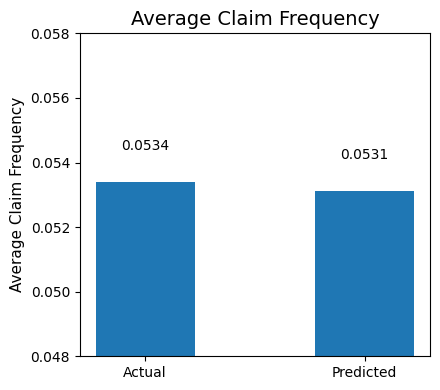

In [301]:
import matplotlib.pyplot as plt

# Average claim frequencies
actual_mean = y_test_v2.mean()
predicted_mean = predictions.mean()

plt.figure(figsize=(4.5, 4))

bars = plt.bar(
    ["Actual", "Predicted"],
    [actual_mean, predicted_mean],
    width=0.45
)

plt.title("Average Claim Frequency", fontsize=14)
plt.ylabel("Average Claim Frequency", fontsize=11)

plt.ylim(0.048, 0.058)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.001,
        f"{height:.4f}",
        ha="center",
        fontsize=10
    )

plt.tight_layout()

plt.savefig(
    "../visualizations/actual_vs_predicted_claim_frequency.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretation

The enhanced Poisson GLM predicts an average claim frequency that is almost identical to the observed average claim frequency.

The close agreement between the two values demonstrates that the model is well calibrated and capable of accurately estimating claim frequencies for unseen insurance policies.

This result provides further evidence that the enhanced model can support insurance pricing decisions by producing realistic expected claim frequencies while maintaining good predictive performance.

## Analysis 37: Residual Diagnostics

### Business Objective

Evaluate the prediction errors (residuals) of the enhanced Poisson GLM.

Residual diagnostics help assess whether the model systematically overestimates or underestimates claim frequencies. A well-performing model should produce residuals that are randomly distributed around zero without obvious patterns.

This analysis provides an additional validation of model adequacy before deployment.

In [302]:
# Calculate prediction residuals

residuals = y_test_v2 - predictions

residuals.head()

261354   -0.0693
448143   -0.0150
188618   -0.0498
12952    -0.0442
425028   -0.0339
dtype: float64

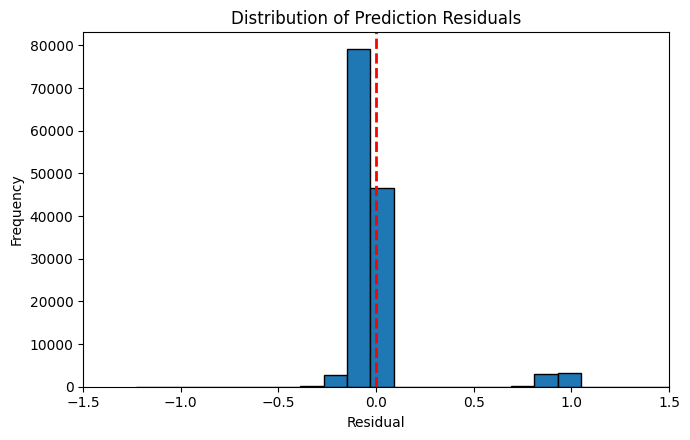

In [303]:
plt.figure(figsize=(7,4.5))

plt.hist(
    residuals,
    bins=60,
    edgecolor="black"
)

plt.axvline(
    0,
    color="red",
    linestyle="--",
    linewidth=2
)

# Zoom into the main residual range
plt.xlim(-1.5, 1.5)

plt.title("Distribution of Prediction Residuals")
plt.xlabel("Residual")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    "../visualizations/residual_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [304]:
residual_summary = residuals.describe().round(4)

residual_summary

count   135,603.0000
mean          0.0003
std           0.2374
min          -1.2295
25%          -0.0747
50%          -0.0435
75%          -0.0128
max           5.9730
dtype: float64

In [305]:
print("Mean Residual:", round(residuals.mean(),6))

Mean Residual: 0.000286


### Interpretation

The residual distribution is centred close to zero, indicating that the enhanced Poisson GLM does not exhibit substantial systematic bias.

Most prediction errors are relatively small, although a few larger residuals remain due to the natural variability of insurance claims.

Overall, the residual analysis supports the adequacy of the enhanced model for predicting motor insurance claim frequency and confirms that the model is appropriately calibrated for pricing applications.

## Analysis 38: Business Conclusions and Recommendations

### Business Objective

The objective of this project was to develop a Generalized Linear Model (GLM) capable of predicting motor insurance claim frequency using historical policyholder information. The resulting model can support insurers in setting risk-based premiums, improving underwriting decisions, and enhancing portfolio profitability.

### Key Findings

The exploratory data analysis identified several important drivers of claim frequency, including:

- Driver age
- Vehicle age
- Bonus-Malus score
- Vehicle brand
- Geographic region
- Population density

Additional feature engineering using grouped driver age, grouped vehicle age, and density categories improved the model's predictive performance compared to the baseline GLM.

### Model Performance

The enhanced Poisson GLM achieved:

- Lower AIC
- Higher Log-Likelihood
- Lower Deviance
- Lower Pearson Chi-Square
- Very small prediction bias
- Mean predicted claim frequency almost identical to the observed claim frequency

Residual diagnostics also demonstrated that prediction errors were centered around zero without obvious systematic bias, indicating that the model is well calibrated.

### Business Impact

The model can be used to:

- Estimate expected claim frequency for new policies.
- Support actuarial premium pricing.
- Improve underwriting decisions.
- Identify higher-risk customer segments.
- Enhance portfolio risk management.
- Provide an interpretable pricing model suitable for regulatory environments.

### Limitations

Several limitations remain:

- The model predicts claim frequency only and does not estimate claim severity.
- Interaction effects between variables were not included.
- Temporal variables such as policy year or seasonality were unavailable.
- More advanced machine learning models may further improve predictive performance.

### Recommendations

Future work could include:

- Gamma GLM for claim severity.
- Tweedie GLM for pure premium modelling.
- Gradient Boosting (XGBoost or LightGBM).
- Random Forest frequency models.
- Cross-validation and hyperparameter optimisation.
- SHAP value analysis for model explainability.

Overall, the enhanced Poisson GLM provides a robust and interpretable framework for predicting motor insurance claim frequency and demonstrates how actuarial modelling techniques can support data-driven insurance pricing.

In [306]:
from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    mean_poisson_deviance
)

mae = mean_absolute_error(y_test_v2, predictions)
rmse = root_mean_squared_error(y_test_v2, predictions)
poisson_dev = mean_poisson_deviance(y_test_v2, predictions)

In [307]:
business_summary = pd.DataFrame({
    "Metric": [
        "Average Actual Claim Frequency",
        "Average Predicted Claim Frequency",
        "Mean Absolute Error",
        "Root Mean Squared Error",
        "Mean Poisson Deviance",
        "Mean Residual"
    ],
    "Value": [
        round(y_test_v2.mean(), 6),
        round(predictions.mean(), 6),
        round(mae, 6),
        round(rmse, 6),
        round(poisson_dev, 6),
        round(residuals.mean(), 6)
    ]
})

business_summary

,Metric,Value
0,Average Actual Claim Frequency,0.0534
1,Average Predicted Claim Frequency,0.0531
2,Mean Absolute Error,0.0989
3,Root Mean Squared Error,0.2374
4,Mean Poisson Deviance,0.3215
5,Mean Residual,0.0003


In [308]:
business_summary.to_csv(
    "../outputs/business_summary.csv",
    index=False
)